<a href="https://colab.research.google.com/github/ThisumiWijesinghe/Pop_Pyramid_Clustering/blob/main/Newest_PopCluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Used PCA for Spec and HIer clustering (get optimal no of clusters and pca components )

Reduced dimensions to: 6


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Optimal clusters based on Silhouette Score: 3


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


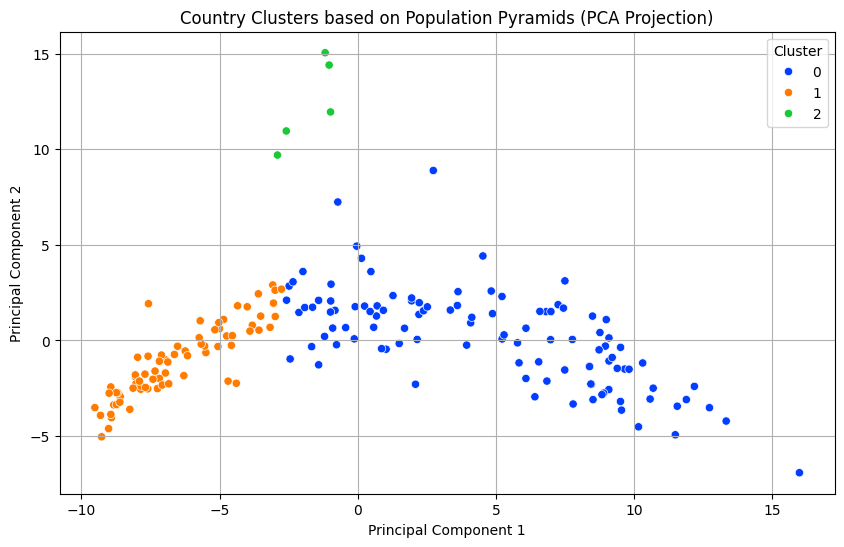

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score

# 1. Load Data
df = pd.read_csv('age_data_1.csv')

# Filter for the year 2020
df_2020 = df[df['Time'] == 2020].copy()

# 2. Feature Engineering for Population Pyramids
# Identify columns representing population counts
population_value_cols = ['PopMale', 'PopFemale', 'PopTotal'] # Assuming these are the population count columns

# Ensure these columns are numeric, coercing errors and filling NaNs with 0
for col in population_value_cols:
    if col in df_2020.columns: # Check if column exists
        df_2020[col] = pd.to_numeric(df_2020[col], errors='coerce').fillna(0)

# Reshape the data for country-level clustering.
# Each row should be a country, and columns should be population counts per age group and gender.
# First, melt the population columns to long format
df_long = df_2020.melt(
    id_vars=['Location', 'Time', 'AgeGrp'],
    value_vars=population_value_cols,
    var_name='PopulationType', # e.g., 'PopMale', 'PopFemale'
    value_name='PopulationValue'
)

# Create a combined 'Feature' column (e.g., 'PopMale_0-4', 'PopFemale_5-9')
df_long['Feature'] = df_long['PopulationType'] + '_' + df_long['AgeGrp']

# Pivot the table to get countries as rows and features as columns
X_pivoted = df_long.pivot_table(
    index='Location',
    columns='Feature',
    values='PopulationValue',
    aggfunc='sum' # Aggregate in case of multiple entries (should ideally be unique per Location-AgeGrp-PopulationType)
)

# Fill any NaNs that might arise from pivoting (e.g., if a country is missing an age group entirely)
X = X_pivoted.fillna(0)

# Ensure all columns in X are numeric after pivoting (should be from previous steps, but safe check)
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# 3. Normalization (Percentage of total population for each country)
# Sum across columns for each country to get its total population represented in X
total_population_per_country = X.sum(axis=1)

# Replace 0 sums with 1 to avoid division by zero errors; countries with 0 total pop will have 0% for all features
total_population_per_country[total_population_per_country == 0] = 1

X_pct = X.div(total_population_per_country, axis=0)

# 4. Standardizing for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pct)

# 5. Dimensionality Reduction (PCA)
pca = PCA(n_components=0.95) # Keep 95% of variance
X_pca = pca.fit_transform(X_scaled)
print(f"Reduced dimensions to: {X_pca.shape[1]}")

# 6. Finding Optimal Clusters (Silhouette Method)
# We test a range to find the best 'k'
scores = []
k_range = range(2, 8)
for k in k_range:
    # Using 'nearest_neighbors' for affinity requires n_neighbors <= n_samples
    # Ensure n_neighbors is not greater than the number of samples (countries)
    n_neighbors_val = min(k + 1, X_pca.shape[0] -1 ) # Ensure n_neighbors is at least 1 and less than n_samples
    if n_neighbors_val < 2: # SpectralClustering requires n_neighbors >= 2
        n_neighbors_val = 2

    sc = SpectralClustering(n_clusters=k, affinity='nearest_neighbors', n_neighbors=n_neighbors_val, random_state=42)
    labels = sc.fit_predict(X_pca)
    # Silhouette score requires at least 2 clusters and more than 1 sample per cluster for meaningful score
    if len(np.unique(labels)) > 1:
        scores.append(silhouette_score(X_pca, labels))
    else:
        scores.append(-1) # Assign a low score if only one cluster found or issue prevents score

# If all scores are -1 (meaning no valid silhouette scores were computed), handle this case
if max(scores) == -1:
    optimal_k = k_range[0] # Default to the smallest k if no valid scores
    print("Warning: Could not compute valid silhouette scores for most k values. Defaulting to smallest k.")
elif len(scores) > 0:
    optimal_k = k_range[np.argmax(scores)]
else:
    optimal_k = 2 # Default to 2 if no scores were appended at all

print(f"Optimal clusters based on Silhouette Score: {optimal_k}")

# 7. Final Clustering
# Ensure n_neighbors is valid for the final model as well
n_neighbors_val_final = min(optimal_k + 1, X_pca.shape[0] -1)
if n_neighbors_val_final < 2:
    n_neighbors_val_final = 2

model = SpectralClustering(n_clusters=optimal_k, affinity='nearest_neighbors', n_neighbors=n_neighbors_val_final, random_state=42)
cluster_labels = model.fit_predict(X_pca)

# Add cluster labels back to the pivoted DataFrame (X_pct or X, as they have 'Location' as index)
X['Cluster'] = cluster_labels

# 8. Visualization of PCA Components
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=X['Cluster'], palette='bright')
plt.title('Country Clusters based on Population Pyramids (PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

#Spectral Clustering - 2020 using PCA

In [ ]:
# 9. Print Country Lists for each Cluster
print("\n" + "="*50)
print("COUNTRY LISTS BY CLUSTER")
print("="*50)

# Define descriptive labels based on common demographic trends
# Note: You can swap these if your PCA projection assigns numbers differently
cluster_meanings = {
    0: "High Growth / Expansive (Young Population)",
    1: "Transitional / Bulge (Working-Age Dividend)",
    2: "Aging / Constrictive (Post-Transitional)"
}

for cluster_id in range(optimal_k):
    # Get index (Country names) where cluster matches
    countries = X[X['Cluster'] == cluster_id].index.tolist()

    label = cluster_meanings.get(cluster_id, f"Cluster {cluster_id}")

    print(f"\n--- {label} ---")
    print(f"Total Count: {len(countries)}")
    # Join list into a comma-separated string for readability
    print(", ".join(countries))
    print("-" * 30)

X[['Cluster']].to_csv('countries_by_cluster.csv')


COUNTRY LISTS BY CLUSTER

--- High Growth / Expansive (Young Population) ---
Total Count: 107
Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Australia, Austria, Azerbaijan, Bahamas, Bangladesh, Barbados, Belarus, Belgium, Bhutan, Bolivia (Plurinational State of), Bosnia and Herzegovina, Brazil, Brunei Darussalam, Bulgaria, Canada, Chile, China, China, Taiwan Province of China, Colombia, Costa Rica, Croatia, Cuba, Curaçao, Cyprus, Czechia, Dem. People's Republic of Korea, Denmark, Dominican Republic, Ecuador, El Salvador, Estonia, Fiji, Finland, France, Georgia, Germany, Greece, Grenada, Guam, Guyana, Hungary, Iceland, India, Indonesia, Iran (Islamic Republic of), Ireland, Israel, Italy, Jamaica, Japan, Kazakhstan, Kuwait, Latvia, Lebanon, Libya, Lithuania, Luxembourg, Malaysia, Malta, Mauritius, Mexico, Mongolia, Montenegro, Morocco, Myanmar, Netherlands, New Zealand, North Macedonia, Northern Europe, Norway, Panama, Peru, Poland, Portugal, Puerto Rico, Republic of Korea, 

#Specral Clustering - 2020 world map

In [ ]:
import plotly.express as px

# 1. Prepare the data for mapping
map_df = X[['Cluster']].reset_index()

# --- FIX FOR DENMARK/GREENLAND ---
# Check if Denmark exists in your data
if 'Denmark' in map_df['Location'].values:
    # Pull the row for Denmark
    denmark_row = map_df[map_df['Location'] == 'Denmark'].copy()
    # Change the name to Greenland
    denmark_row['Location'] = 'Greenland'
    # Add it back to the dataframe
    map_df = pd.concat([map_df, denmark_row], ignore_index=True)
# ---------------------------------

# 2. Define Descriptive Labels
cluster_labels = {
    0: "Cluster 0: High Growth (Young)",
    1: "Cluster 1: Transitional (Working Age)",
    2: "Cluster 2: Aging (Post-Transitional)"
}
map_df['Demographic Stage'] = map_df['Cluster'].map(cluster_labels)

# 3. Create the Interactive Choropleth Map
fig = px.choropleth(
    map_df,
    locations="Location",
    locationmode="country names",
    color="Demographic Stage",
    hover_name="Location",
    title="Global Demographic Clusters 2020 (Including Greenland/Denmark Fix)",
    color_discrete_sequence=px.colors.qualitative.Safe
)

# 4. Refine Map Appearance
fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
    ),
    legend_title_text='Demographic Cluster',
    margin={"r":0,"t":50,"l":0,"b":0}
)

fig.show()

# 10 Countries spec- 2020

<>:13: SyntaxWarning:

invalid escape sequence '\d'

<>:13: SyntaxWarning:

invalid escape sequence '\d'

/tmp/ipykernel_20367/3178899652.py:13: SyntaxWarning:

invalid escape sequence '\d'

/tmp/ipykernel_20367/3178899652.py:47: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_20367/3178899652.py:47: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_20367/3178899652.py:47: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_20367/3178899652.py:47: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_20367/3178899652.py:47: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after se

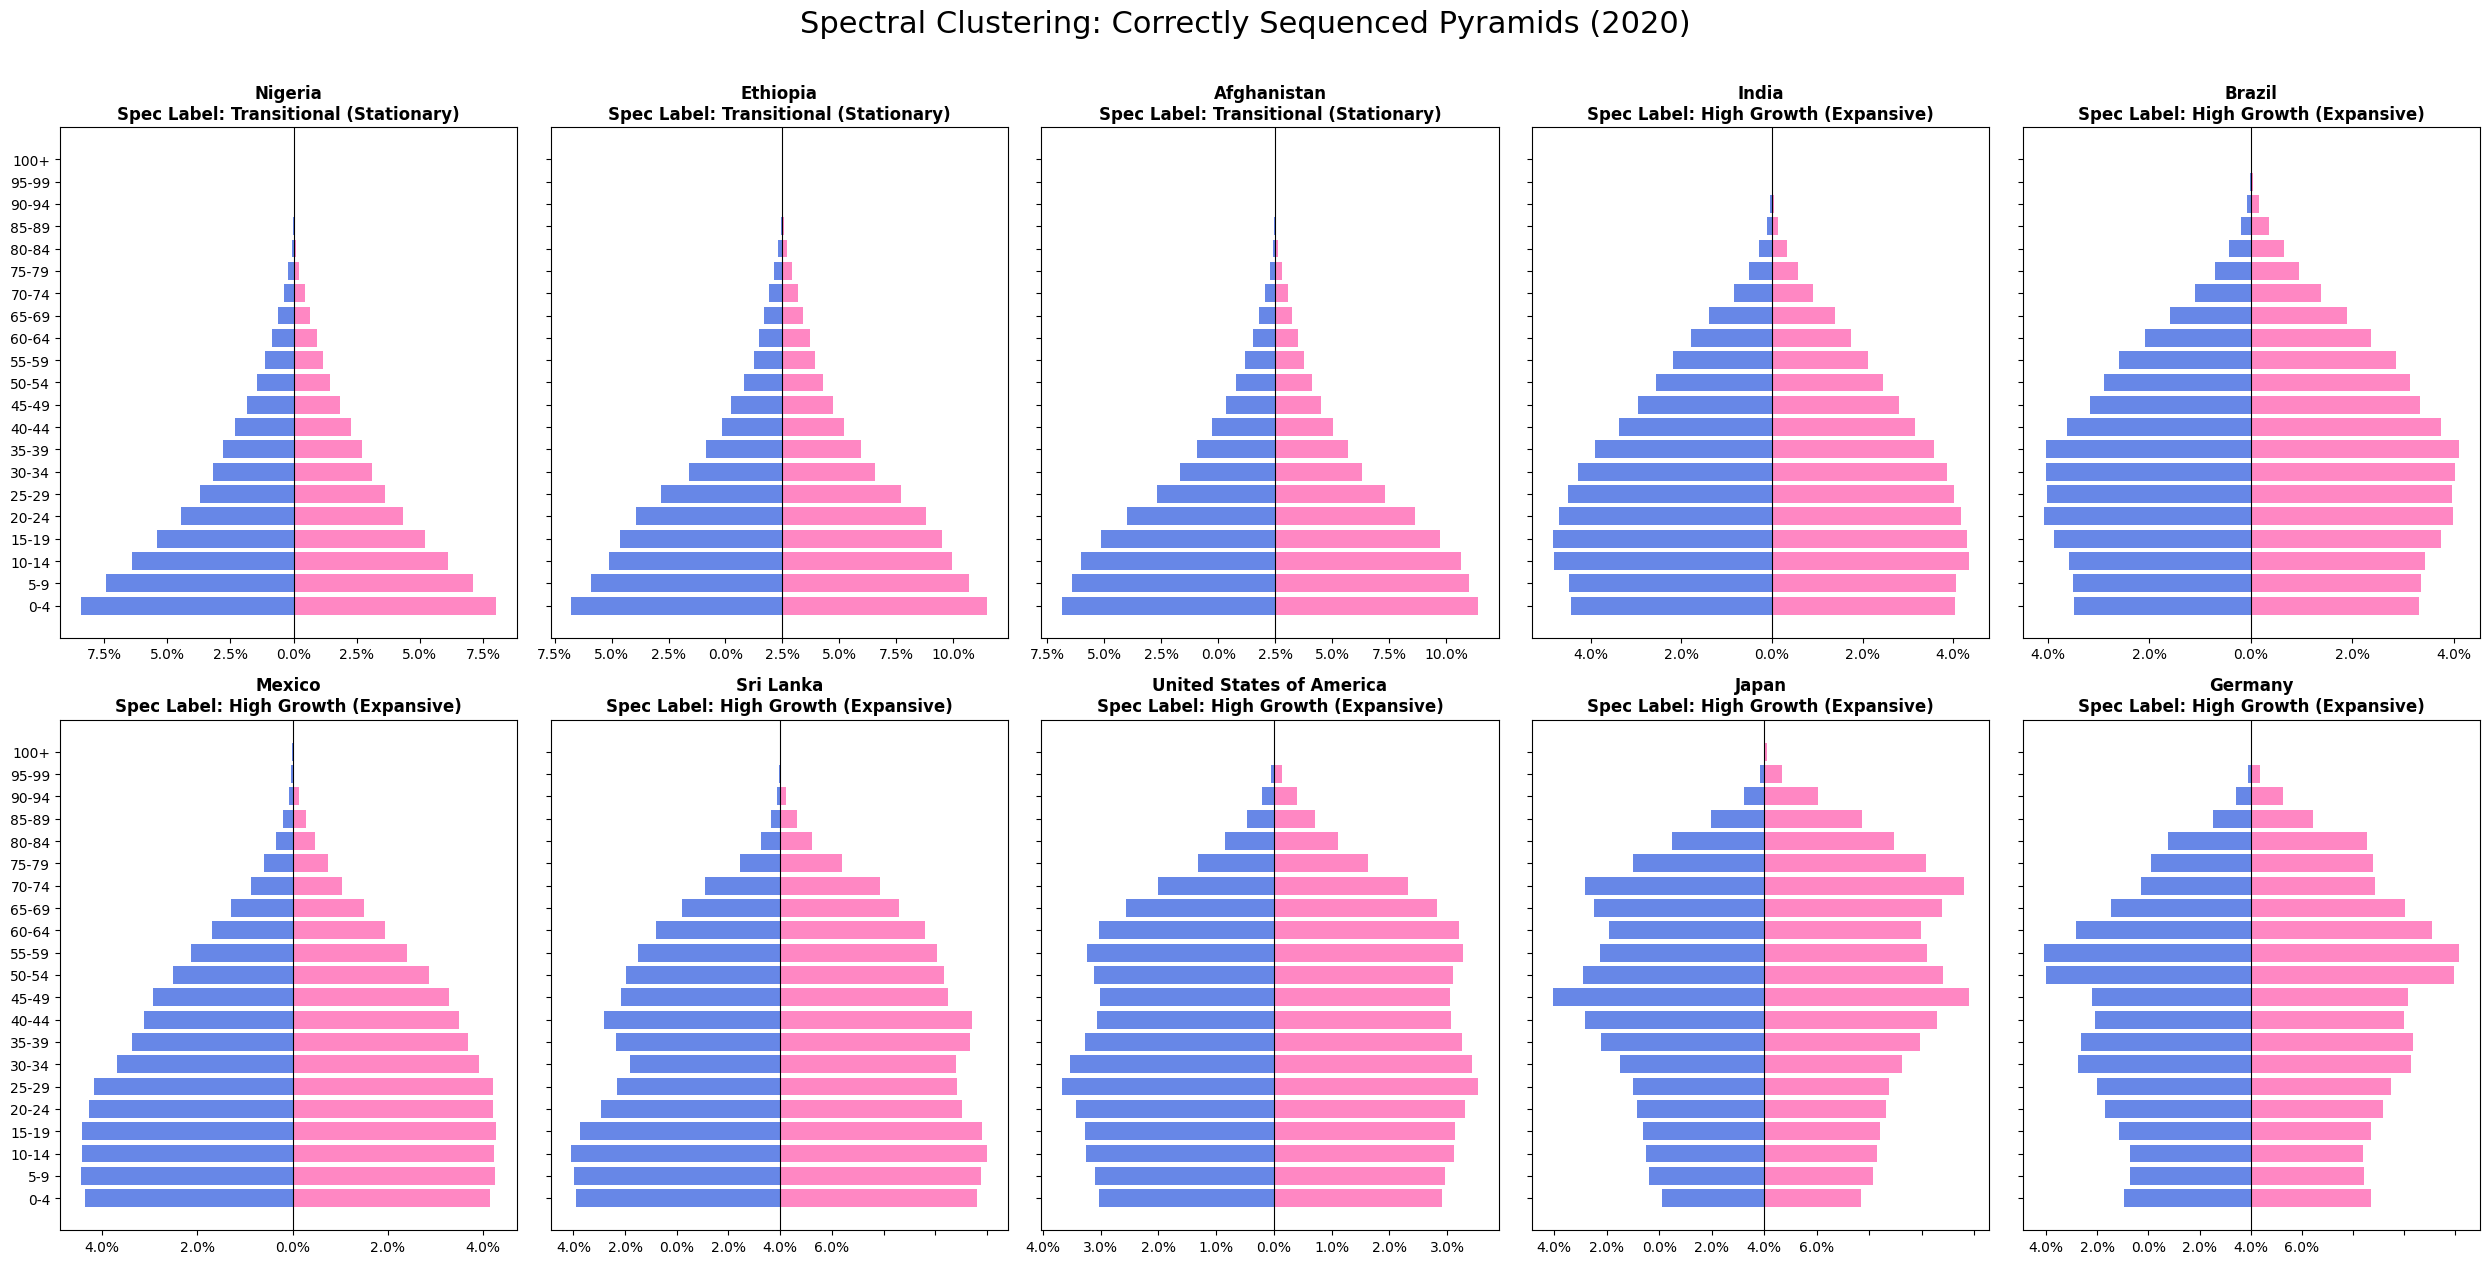

In [ ]:
import matplotlib.pyplot as plt

# 1. Choose your 10 countries
countries_10 = ['Nigeria', 'Ethiopia', 'Afghanistan', 'India', 'Brazil',
                'Mexico', 'Sri Lanka', 'United States of America', 'Japan', 'Germany']

# 2. Setup the plot
fig, axes = plt.subplots(2, 5, figsize=(25, 12), sharey=True)
axes = axes.flatten()

# --- IMPORTANT: Create a sorting helper ---
# We extract the first number from the AgeGrp string (e.g., "5-9" -> 5) to sort correctly
df['age_sort'] = df['AgeGrp'].str.extract('(\d+)').astype(float)

# Define the spectral labels map (re-using from a previous cell or defining if needed)
spectral_labels_map = {
    0: "High Growth (Expansive)",
    1: "Transitional (Stationary)",
    2: "Aging (Constrictive)"
}

# Add 'Spectral_Label' to X DataFrame
X['Spectral_Label'] = X['Cluster'].map(spectral_labels_map)

for i, country in enumerate(countries_10):
    ax = axes[i]

    # Filter and SORT by our new helper column
    data = df[(df['Location'] == country) & (df['Time'] == 2020)].sort_values('age_sort')

    if data.empty: continue

    label = X.loc[country, 'Spectral_Label']
    total = data['PopTotal'].sum()
    m_pct = (data['PopMale'] / total) * 100
    f_pct = (data['PopFemale'] / total) * 100

    # Plot
    ax.barh(data['AgeGrp'], -m_pct, color='royalblue', alpha=0.8, label='Male')
    ax.barh(data['AgeGrp'], f_pct, color='hotpink', alpha=0.8, label='Female')
    ax.axvline(0, color='black', linewidth=0.8)

    ax.set_title(f"{country}\nSpec Label: {label}", fontsize=12, fontweight='bold')

    # Formatting X-axis to show positive numbers on both sides
    ticks = ax.get_xticks()
    ax.set_xticklabels([f"{abs(x):.1f}%" for x in ticks])

plt.tight_layout()
plt.suptitle("Spectral Clustering: Correctly Sequenced Pyramids (2020)", fontsize=22, y=1.05)
plt.show()

#Apply UMAP for visulaization

In [ ]:
import umap
from sklearn.preprocessing import StandardScaler

# Standardize the percentage data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pct)

# Apply UMap
# n_neighbors: looks at local vs global structure (15 is a good balance)
# min_dist: how tightly points pack together (0.1 is standard)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_scaled)

# Add UMap coordinates to our dataframe for easy plotting
X['UMAP_1'] = X_umap[:, 0]
X['UMAP_2'] = X_umap[:, 1]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



###Spectral Clustering UMAP

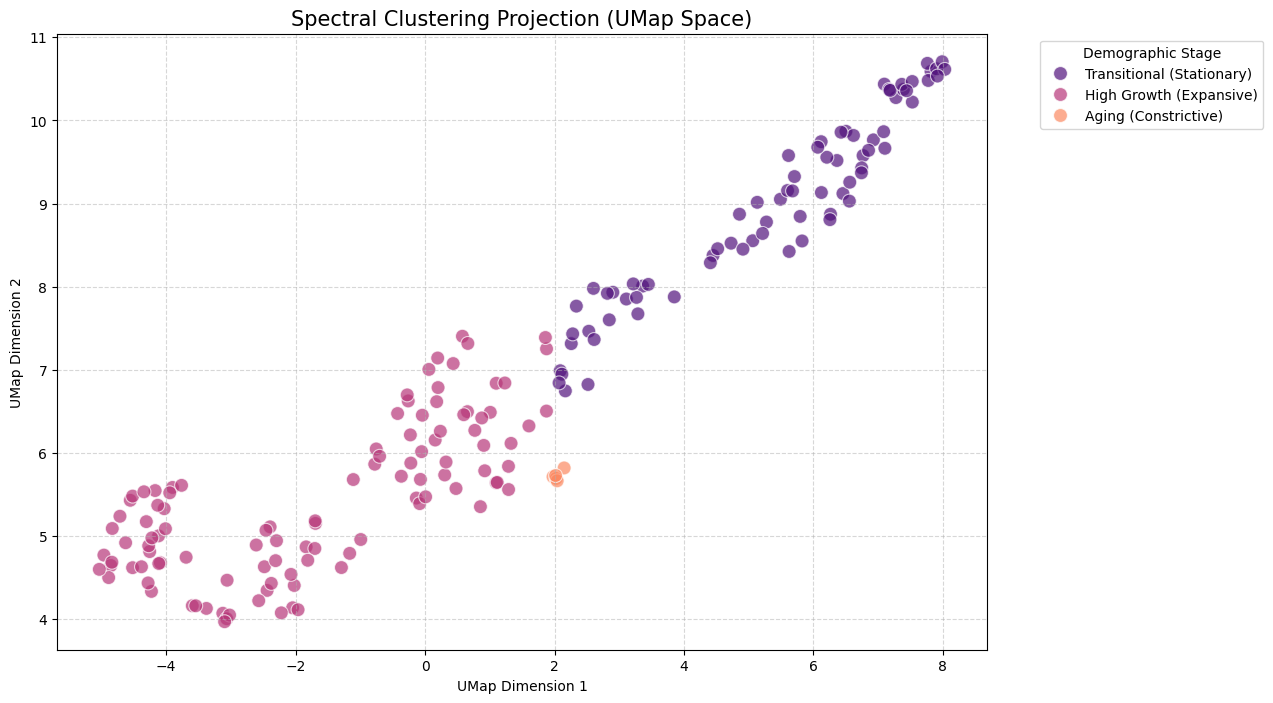

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# We use the Cluster labels already generated by your Spectral model
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='UMAP_1', y='UMAP_2',
    hue='Spectral_Label',
    data=X,
    palette='magma', # Uses a rainbow-like palette for stages
    s=100, alpha=0.7, edgecolor='w'
)

plt.title('Spectral Clustering Projection (UMap Space)', fontsize=15)
plt.xlabel('UMap Dimension 1')
plt.ylabel('UMap Dimension 2')
plt.legend(title='Demographic Stage', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#No of spectral clusters for 1950-2100

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.linalg import eigsh
from scipy.sparse import csgraph
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- Parameters ---
n_neighbors = 5       # neighbors for spectral graph
max_clusters = 10     # max clusters to consider
plot_eigen_graphs = False  # set True if you want a graph per year

# --- Prepare summary list ---
optimal_clusters_summary = []

years = sorted(df['Time'].unique())

for year in years:
    # 1. Pivot data for the year
    X_year = df[df['Time']==year].pivot_table(index='Location', columns='AgeGrp', values='PopTotal').fillna(0)

    # Avoid division by zero
    X_year_pct = X_year.div(X_year.sum(axis=1).replace(0,1), axis=0)

    # 2. Standardize and PCA
    X_scaled = StandardScaler().fit_transform(X_year_pct)
    X_pca = PCA(n_components=0.95).fit_transform(X_scaled)

    # 3. Build nearest neighbor graph and Laplacian
    A = kneighbors_graph(X_pca, n_neighbors=min(n_neighbors, X_pca.shape[0]-1), include_self=True)
    L = csgraph.laplacian(A, normed=True)

    # 4. Compute smallest eigenvalues
    k_compute = min(max_clusters+1, X_pca.shape[0]-1)  # cannot exceed n_samples-1
    eigenvalues, _ = eigsh(L, k=k_compute, which='SM')
    eigenvalues = np.sort(eigenvalues)

    # 5. Compute gaps and find optimal k
    gaps = np.diff(eigenvalues)
    optimal_k = np.argmax(gaps) + 1

    # Save results
    optimal_clusters_summary.append({
        'Year': year,
        'Optimal_Spectral_k': optimal_k,
        'Eigenvalues': eigenvalues,
        'Gaps': gaps
    })

    # 6. Optional: plot eigen-graph per year
    if plot_eigen_graphs:
        plt.figure(figsize=(8,4))
        plt.plot(range(1,len(eigenvalues)+1), eigenvalues, marker='o', label='Eigenvalues')
        plt.axvline(optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k}')
        plt.title(f"Spectral Clustering Eigen-Graph ({year})")
        plt.xlabel("Index of Eigenvalue")
        plt.ylabel("Eigenvalue")
        plt.grid(True)
        plt.legend()
        plt.show()

# Convert summary to DataFrame
optimal_clusters_df = pd.DataFrame(optimal_clusters_summary)
print(optimal_clusters_df[['Year', 'Optimal_Spectral_k']])

# Optional: save to CSV for your report
optimal_clusters_df.to_csv('spectral_optimal_clusters_1950_2100.csv', index=False)
print("\nSaved optimal spectral clusters per year to 'spectral_optimal_clusters_1950_2100.csv'")

     Year  Optimal_Spectral_k
0    1950                   1
1    1951                   2
2    1952                   8
3    1953                   4
4    1954                   8
..    ...                 ...
146  2096                   1
147  2097                   8
148  2098                   3
149  2099                   5
150  2100                   1

[151 rows x 2 columns]

Saved optimal spectral clusters per year to 'spectral_optimal_clusters_1950_2100.csv'


#New Part

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph
from scipy.sparse import csgraph
from sklearn.cluster import SpectralClustering

# -----------------------------
# PARAMETERS
# -----------------------------
years = list(range(1950, 2101, 10))   # 10-year intervals (you can change to 20)
n_neighbors = 5

all_results = []

# -----------------------------
# MAIN LOOP
# -----------------------------
for year in years:

    df_year = df[df['Time'] == year]

    if len(df_year) < 3:
        continue

    # Pivot (countries x age groups)
    X = df_year.pivot_table(
        index='Location',
        columns='AgeGrp',
        values='PopTotal'
    ).fillna(0)

    countries = X.index
    age_groups = X.columns

    # Normalize (population proportion)
    X_pct = X.div(X.sum(axis=1).replace(0,1), axis=0)

    # Standardize + PCA
    X_scaled = StandardScaler().fit_transform(X_pct)
    X_pca = PCA(n_components=0.95).fit_transform(X_scaled)

    # Graph (for clustering stability)
    A = kneighbors_graph(
        X_pca,
        n_neighbors=min(n_neighbors, len(X_pca)-1),
        include_self=True
    )
    L = csgraph.laplacian(A, normed=True)

    # --- choose k using heuristic (fixed small k for stability) ---
    k = min(5, len(X_pca)-1)

    # Spectral Clustering
    model = SpectralClustering(
        n_clusters=k,
        affinity='nearest_neighbors',
        random_state=42
    )
    labels = model.fit_predict(X_pca)

    X_pct['Cluster'] = labels

    # -----------------------------
    # Overall mean distribution
    # -----------------------------
    overall_mean = X_pct.drop(columns='Cluster').mean()

    # -----------------------------
    # Cluster-wise analysis
    # -----------------------------
    for c in sorted(X_pct['Cluster'].unique()):

        cluster_data = X_pct[X_pct['Cluster'] == c].drop(columns='Cluster')

        cluster_mean = cluster_data.mean()
        num_countries = len(cluster_data)

        row = {
            'Year': year,
            'Cluster': c,
            'Num_Countries': num_countries,
            'Type': 'Cluster'
        }

        # add age group distribution
        for ag in age_groups:
            row[ag] = cluster_mean[ag]

        all_results.append(row)

    # Add overall distribution
    overall_row = {
        'Year': year,
        'Cluster': 'Overall',
        'Num_Countries': len(X_pct),
        'Type': 'Overall'
    }

    for ag in age_groups:
        overall_row[ag] = overall_mean[ag]

    all_results.append(overall_row)

# -----------------------------
# FINAL DATAFRAME
# -----------------------------
result_df = pd.DataFrame(all_results)

print(result_df.head())

   Year Cluster  Num_Countries     Type       0-4     10-14      100+  \
0  1950       0             37  Cluster  0.168781  0.117305  0.000032   
1  1950       1             31  Cluster  0.179623  0.122744  0.000001   
2  1950       2             43  Cluster  0.110027  0.102477  0.000016   
3  1950       3             60  Cluster  0.152189  0.107487  0.000002   
4  1950       4             16  Cluster  0.092330  0.071109  0.000009   

      15-19     20-24     25-29  ...     50-54     55-59     60-64     65-69  \
0  0.099712  0.085752  0.072313  ...  0.033164  0.026454  0.021852  0.016067   
1  0.105801  0.090092  0.075770  ...  0.028644  0.022145  0.017094  0.012080   
2  0.095059  0.093494  0.075150  ...  0.046407  0.037740  0.034660  0.027781   
3  0.098857  0.091519  0.080109  ...  0.035834  0.027955  0.022053  0.016316   
4  0.069860  0.073020  0.076984  ...  0.060904  0.051679  0.045232  0.037741   

      70-74     75-79     80-84     85-89     90-94     95-99  
0  0.011581  0.0

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning:

Graph is not fully connected, spectral embedding may not work as expected.



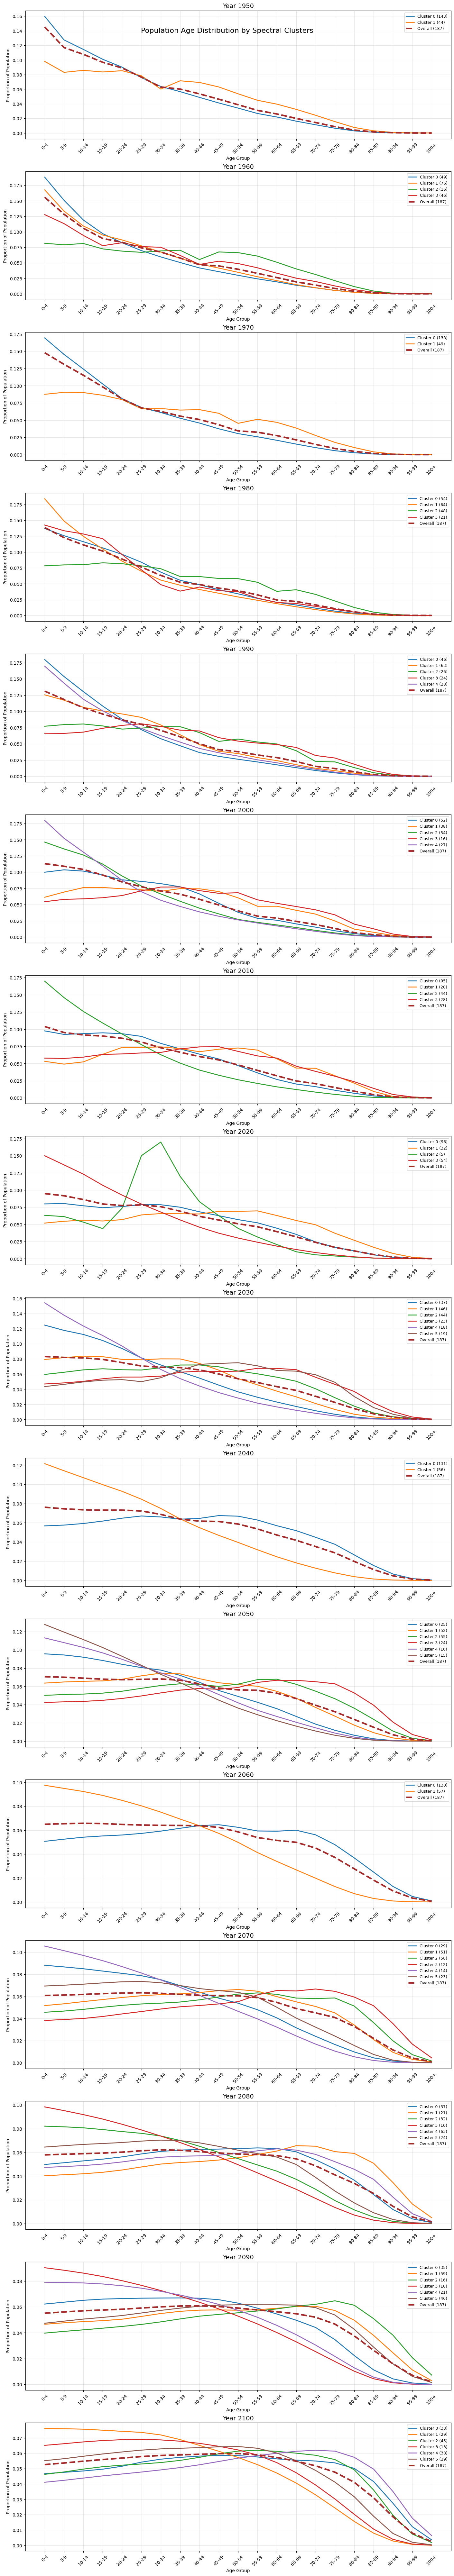

Plotting complete. Results saved to 'population_age_clusters_spectral.csv'


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph
from scipy.sparse import csgraph
from scipy.sparse.linalg import eigsh
from sklearn.cluster import SpectralClustering

# ============================
# ASSUMPTIONS / SETUP
# ============================
# df should have columns: 'Time', 'Location', 'AgeGrp', 'PopTotal'
# Example: load your data here if not already loaded
# df = pd.read_csv("your_population_data.csv")

# ============================
# HELPER FUNCTIONS
# ============================
def extract_age_start(x):
    """Extract starting age number from AgeGrp like '0-4', '5-9', etc."""
    num = re.findall(r'\d+', x)
    return int(num[0]) if num else 999

def get_optimal_k(X_pca, max_k=8):
    """Use spectral gap heuristic to find optimal number of clusters."""
    if len(X_pca) < 3:
        return 2
    n_neighbors = min(5, len(X_pca) - 1)
    A = kneighbors_graph(X_pca, n_neighbors=n_neighbors, include_self=True)
    L = csgraph.laplacian(A, normed=True)

    k_compute = min(max_k + 2, len(X_pca) - 1)
    eigenvalues, _ = eigsh(L, k=k_compute, which='SM')
    eigenvalues = np.sort(eigenvalues)
    gaps = np.diff(eigenvalues)
    optimal_k = np.argmax(gaps) + 1
    return max(2, min(optimal_k, max_k))  # at least 2, at most max_k

# ============================
# MAIN PROCESSING
# ============================
years_to_analyze = list(range(1950, 2101, 10))  # every 10 years

all_results = []
age_cols = None

for year in years_to_analyze:
    df_year = df[df['Time'] == year].copy()
    if len(df_year) < 5:  # too few countries
        continue

    # Pivot: rows = countries, columns = age groups
    X = df_year.pivot_table(
        index='Location',
        columns='AgeGrp',
        values='PopTotal',
        fill_value=0
    )

    countries = X.index.tolist()
    if age_cols is None:
        age_cols = sorted(X.columns.tolist(), key=extract_age_start)

    # Convert to proportions
    X_pct = X.div(X.sum(axis=1).replace(0, 1), axis=0)

    # Standardize + PCA (reduce noise)
    X_scaled = StandardScaler().fit_transform(X_pct)
    pca = PCA(n_components=0.95, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    # Determine optimal k via spectral gap
    k = get_optimal_k(X_pca, max_k=6)

    # Perform Spectral Clustering
    clustering = SpectralClustering(
        n_clusters=k,
        affinity='nearest_neighbors',
        n_neighbors=5,
        random_state=42,
        assign_labels='kmeans'
    )
    labels = clustering.fit_predict(X_pca)

    X_pct = X_pct.copy()
    X_pct['Cluster'] = labels
    X_pct['Location'] = countries  # for reference if needed

    # Overall mean
    overall_mean = X_pct.drop(columns=['Cluster'], errors='ignore').mean(numeric_only=True)

    # Cluster means
    for c in range(k):
        cluster_df = X_pct[X_pct['Cluster'] == c].drop(columns=['Cluster'], errors='ignore')
        cluster_mean = cluster_df.mean(numeric_only=True)
        num_countries = len(cluster_df)

        row = {'Year': year, 'Cluster': c, 'Num_Countries': num_countries}
        for ag in age_cols:
            row[ag] = cluster_mean.get(ag, 0)
        all_results.append(row)

    # Overall
    overall_row = {'Year': year, 'Cluster': 'Overall', 'Num_Countries': len(X_pct)}
    for ag in age_cols:
        overall_row[ag] = overall_mean.get(ag, 0)
    all_results.append(overall_row)

# ============================
# CREATE RESULT DATAFRAME
# ============================
result_df = pd.DataFrame(all_results)

# ============================
# PLOTTING - Like your image (one plot per selected year)
# ============================
plot_years = [1950, 1960, 1970, 1980,1990, 2000, 2010, 2020, 2030, 2040, 2050, 2060, 2070,2080, 2090, 2100]  # customize as needed

n_plots = len(plot_years)
fig, axes = plt.subplots(n_plots, 1, figsize=(14, 5 * n_plots), constrained_layout=True)

if n_plots == 1:
    axes = [axes]

for i, year in enumerate(plot_years):
    ax = axes[i]
    df_plot = result_df[result_df['Year'] == year]

    if df_plot.empty:
        ax.text(0.5, 0.5, f'No data for {year}', ha='center', va='center')
        continue

    for _, row in df_plot.iterrows():
        values = [row[ag] for ag in age_cols]

        if row['Cluster'] == 'Overall':
            ax.plot(age_cols, values,
                    color='brown',
                    linestyle='--',
                    linewidth=3.5,
                    label=f"Overall ({int(row['Num_Countries'])})")
        else:
            color = plt.cm.tab10(int(row['Cluster']) % 10)
            ax.plot(age_cols, values,
                    label=f"Cluster {int(row['Cluster'])} ({int(row['Num_Countries'])})",
                    color=color,
                    linewidth=2)

    ax.set_title(f"Year {year}", fontsize=14)
    ax.set_xlabel("Age Group")
    ax.set_ylabel("Proportion of Population")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='upper right')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Population Age Distribution by Spectral Clusters", fontsize=16, y=0.99)
plt.show()

# Optional: Save results
result_df.to_csv('population_age_clusters_spectral.csv', index=False)
print("Plotting complete. Results saved to 'population_age_clusters_spectral.csv'")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning:

Graph is not fully connected, spectral embedding may not work as expected.



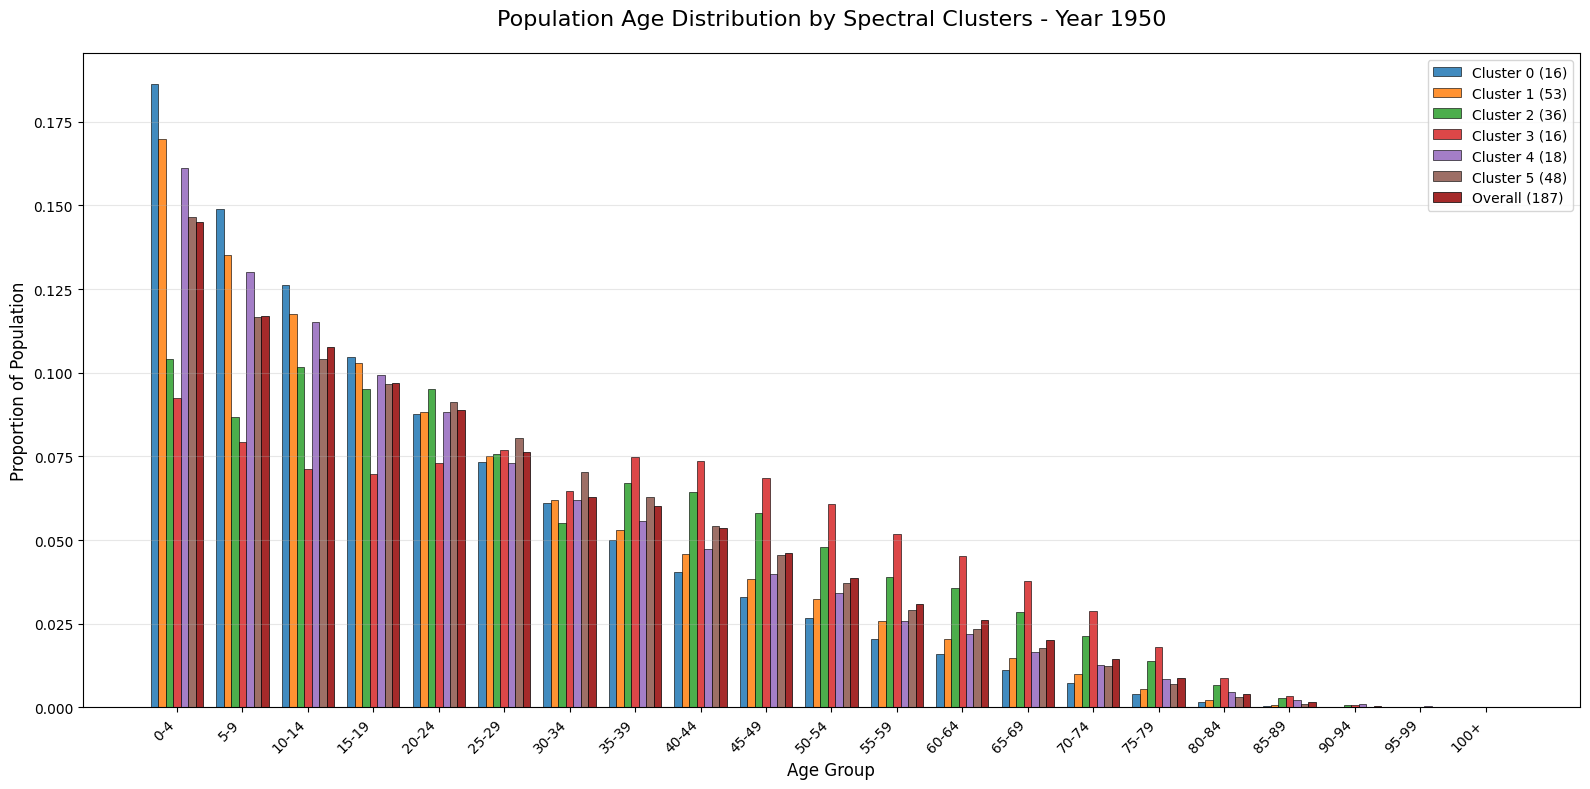

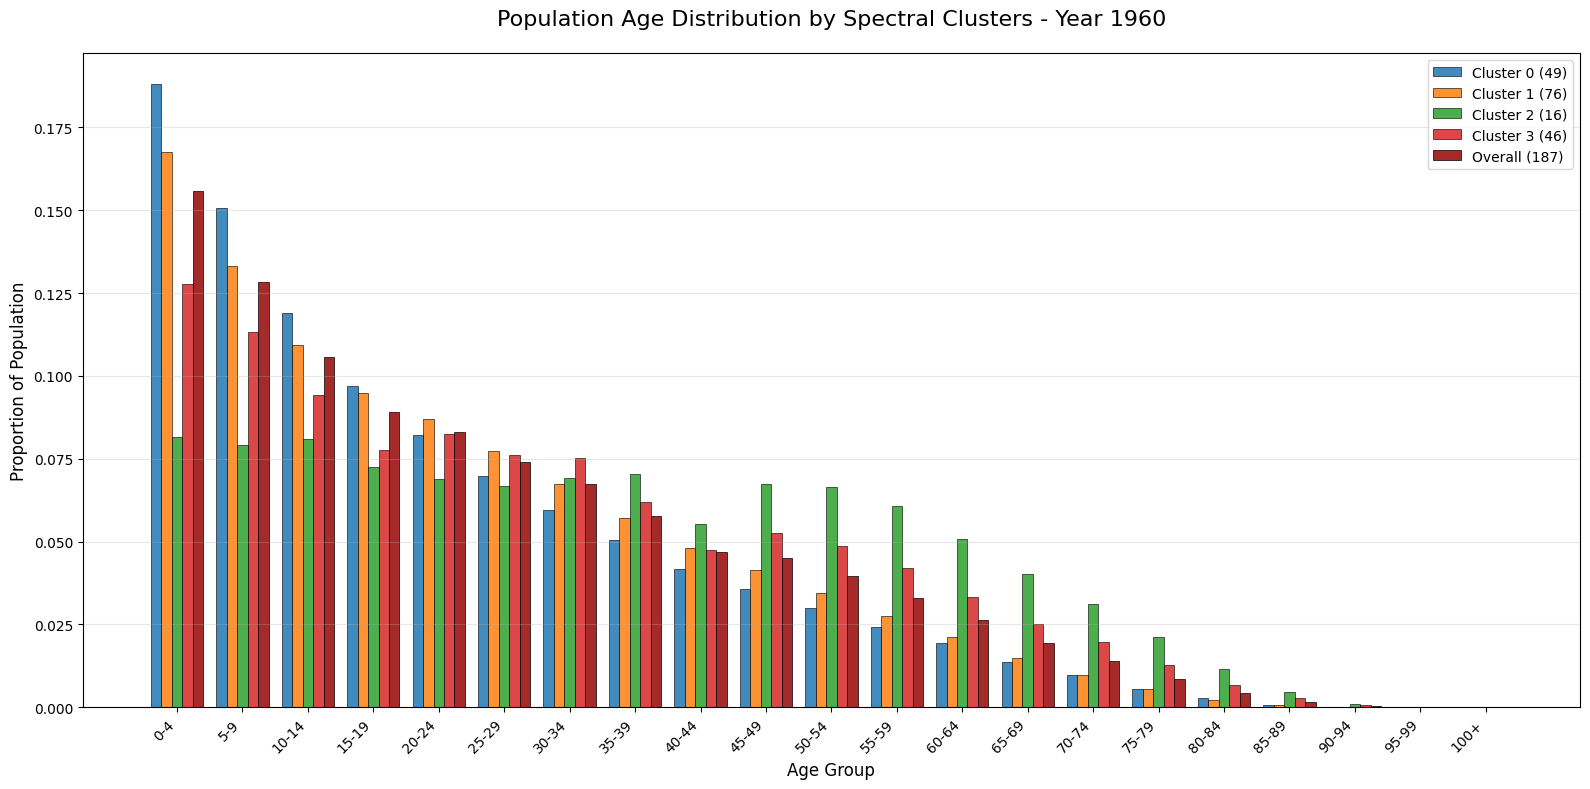

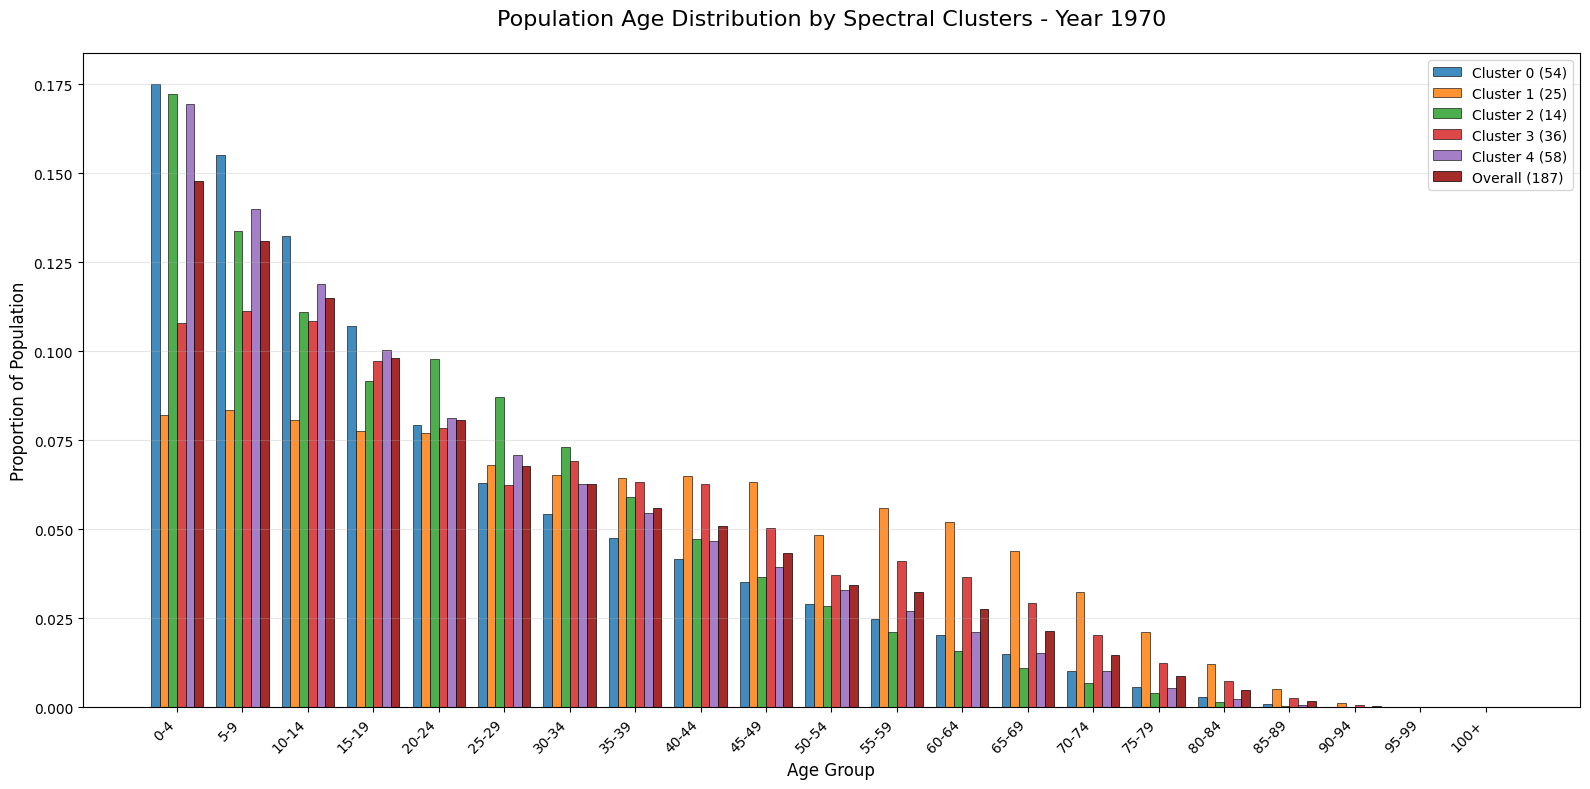

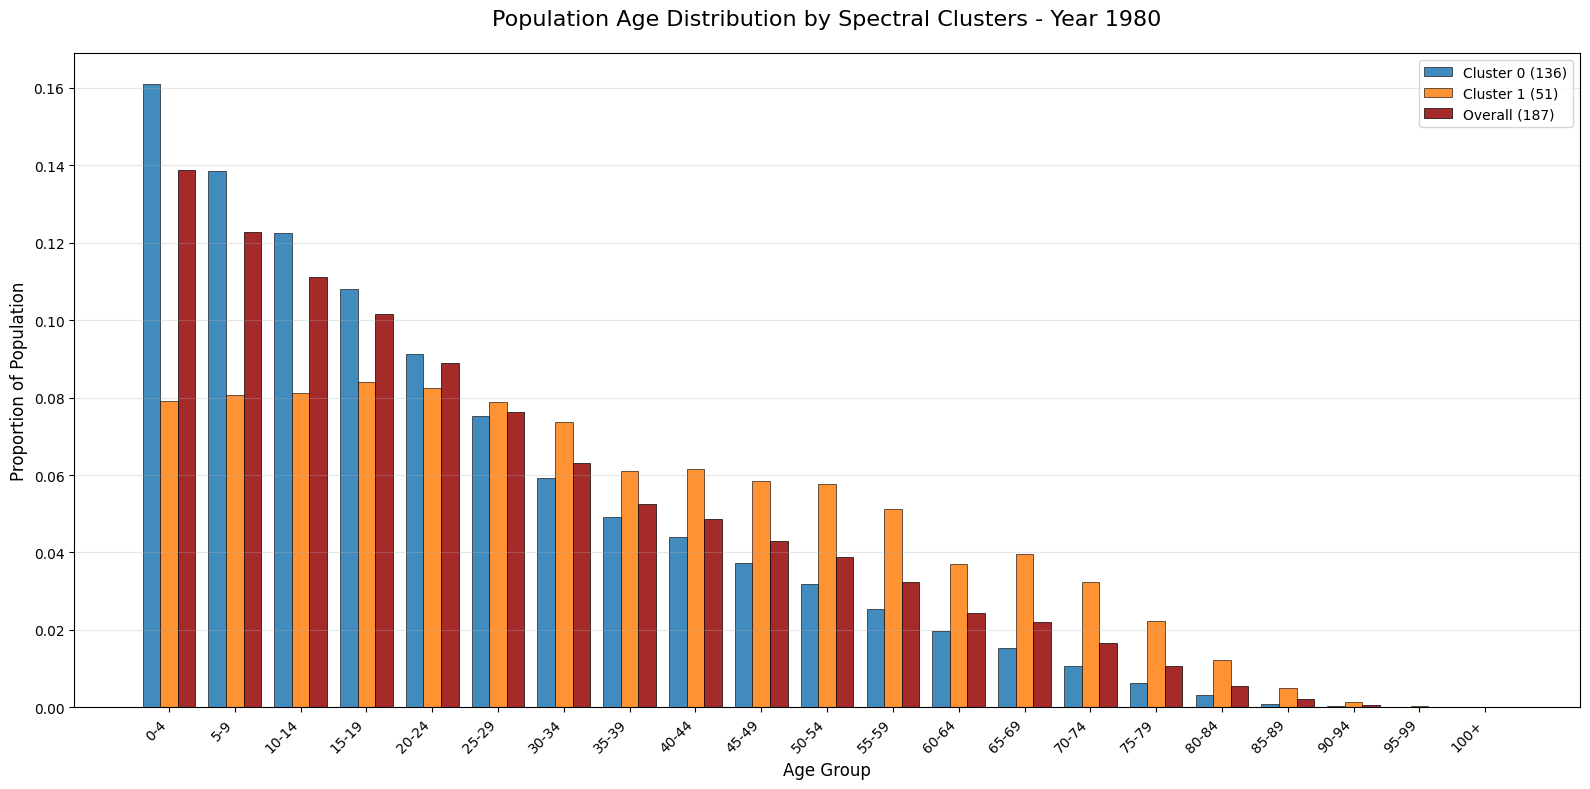

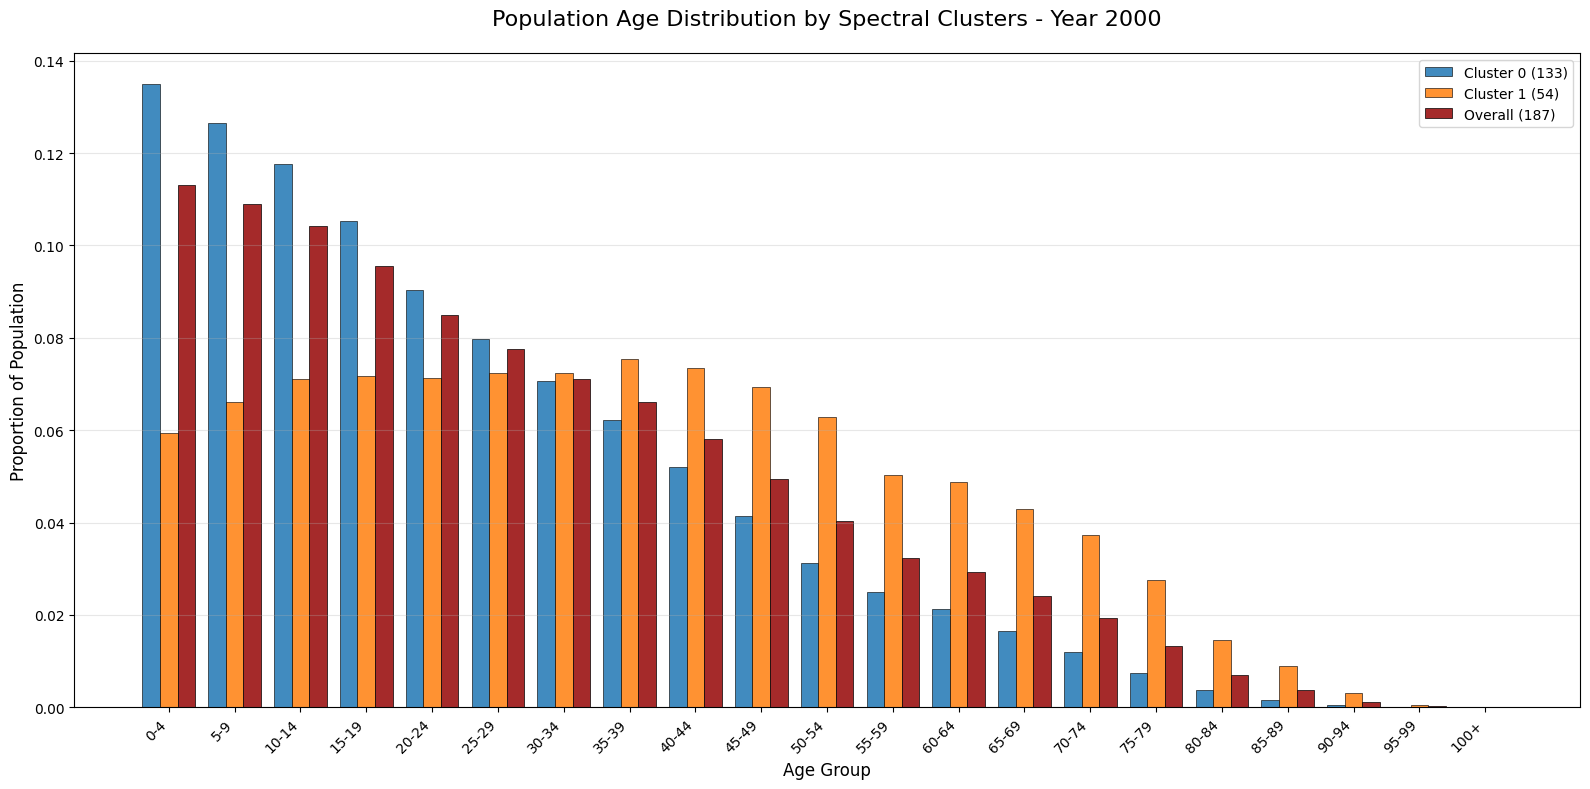

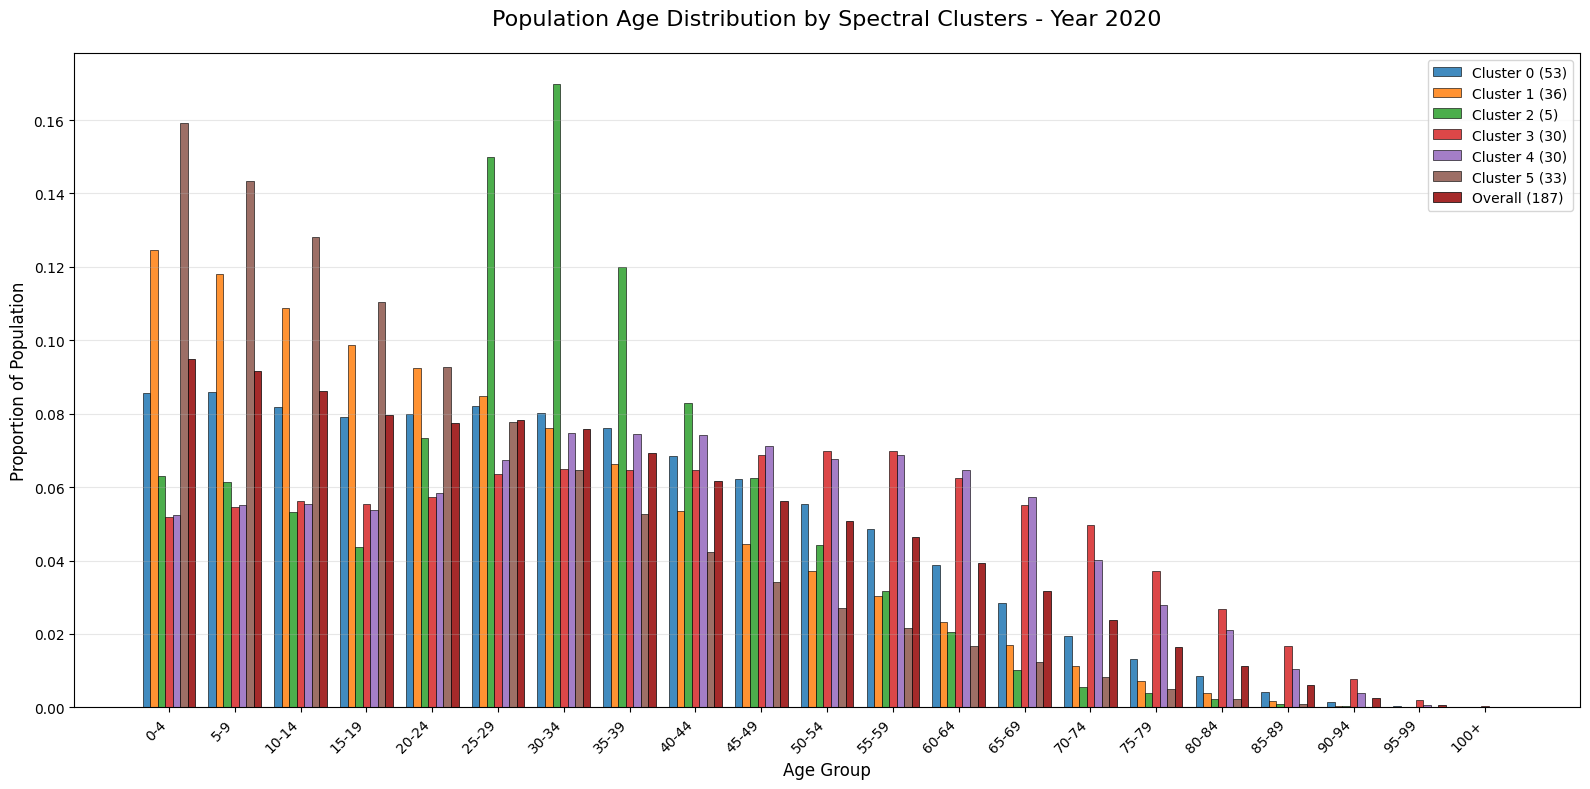

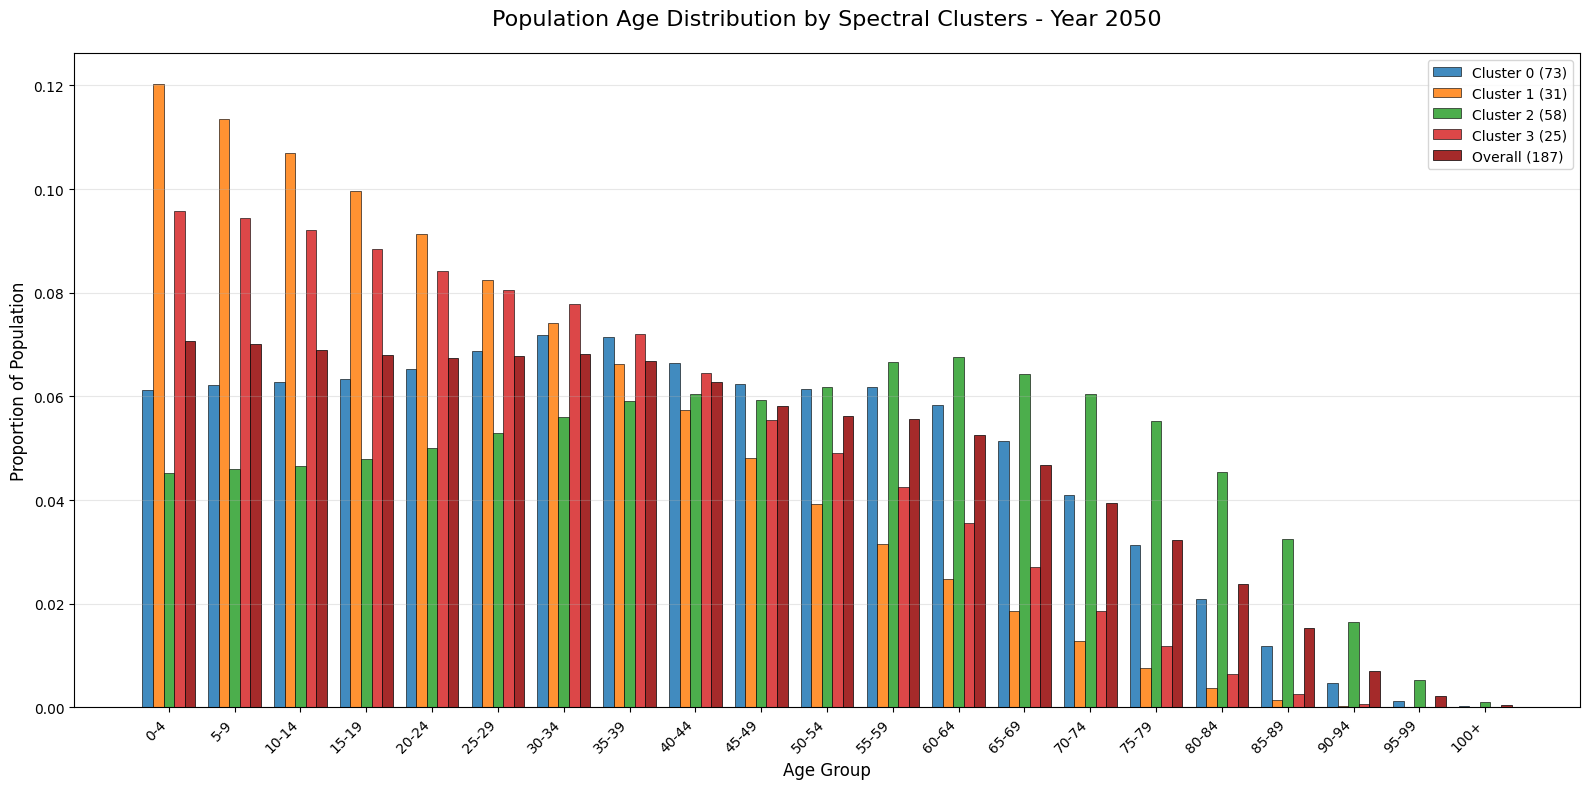

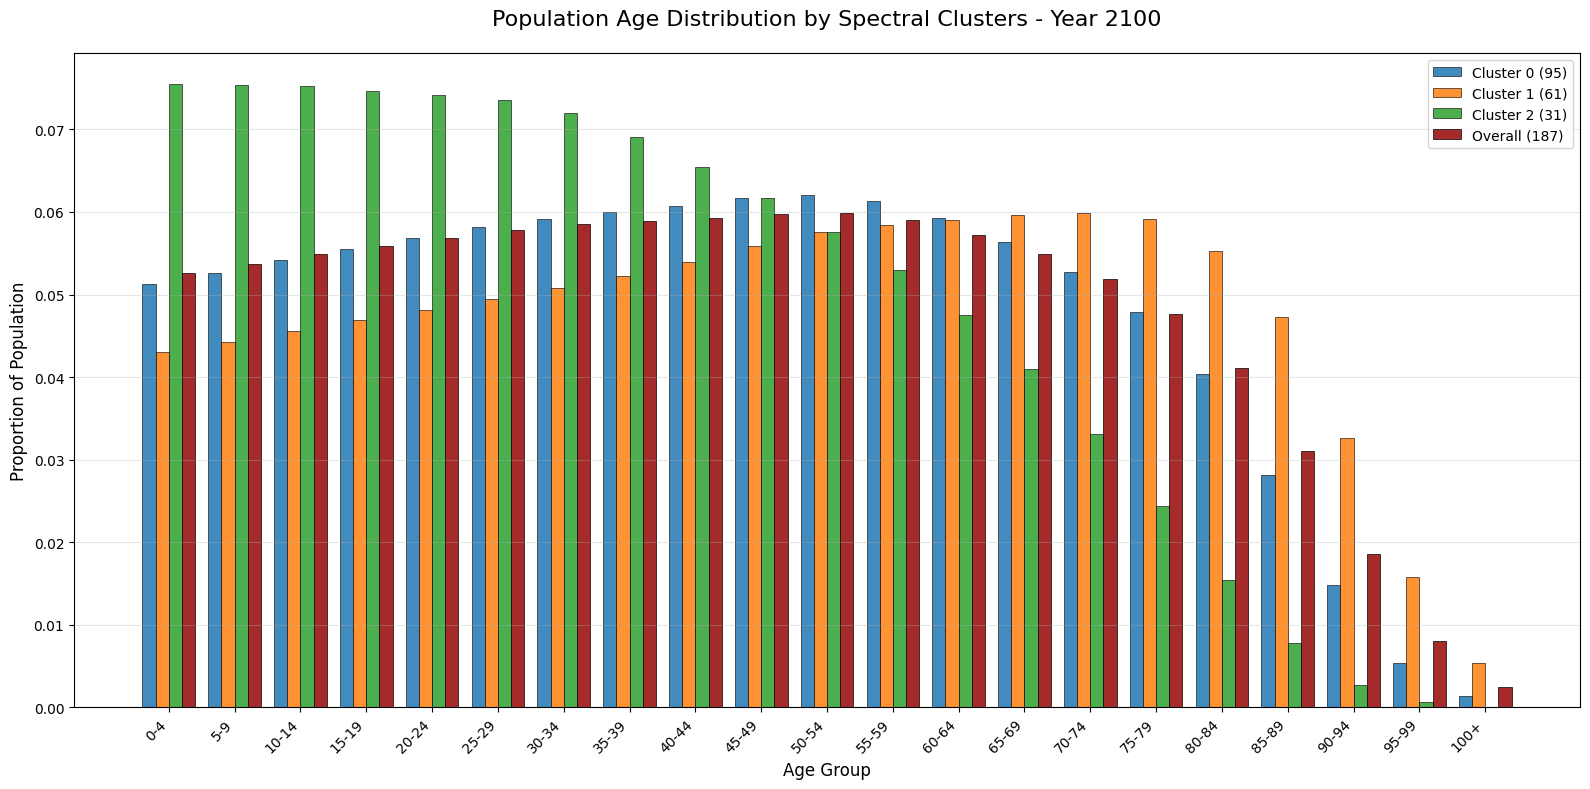

 Bar plots generated and results saved!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph
from scipy.sparse import csgraph
from scipy.sparse.linalg import eigsh
from sklearn.cluster import SpectralClustering

# ============================
# HELPER FUNCTIONS
# ============================
def extract_age_start(x):
    num = re.findall(r'\d+', str(x))
    return int(num[0]) if num else 999

def get_optimal_k(X_pca, max_k=6):
    if len(X_pca) < 4:
        return 3
    n_neighbors = min(5, len(X_pca) - 1)
    A = kneighbors_graph(X_pca, n_neighbors=n_neighbors, include_self=True)
    L = csgraph.laplacian(A, normed=True)

    k_compute = min(max_k + 2, len(X_pca) - 1)
    eigenvalues, _ = eigsh(L, k=k_compute, which='SM')
    eigenvalues = np.sort(eigenvalues)
    gaps = np.diff(eigenvalues)
    optimal_k = np.argmax(gaps) + 1
    return max(2, min(optimal_k, max_k))

# ============================
# MAIN CLUSTERING
# ============================
years_to_analyze = list(range(1950, 2101, 10))

all_results = []
age_cols = None

for year in years_to_analyze:
    df_year = df[df['Time'] == year].copy()
    if len(df_year) < 5:
        continue

    X = df_year.pivot_table(index='Location', columns='AgeGrp', values='PopTotal', fill_value=0)
    countries = X.index.tolist()

    if age_cols is None:
        age_cols = sorted(X.columns.tolist(), key=extract_age_start)

    X_pct = X.div(X.sum(axis=1).replace(0, 1), axis=0)

    X_scaled = StandardScaler().fit_transform(X_pct)
    pca = PCA(n_components=0.95, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    k = get_optimal_k(X_pca, max_k=6)

    clustering = SpectralClustering(
        n_clusters=k,
        affinity='nearest_neighbors',
        n_neighbors=5,
        random_state=42,
        assign_labels='kmeans'
    )
    labels = clustering.fit_predict(X_pca)

    X_pct = X_pct.copy()
    X_pct['Cluster'] = labels

    # Overall mean
    overall_mean = X_pct.drop(columns=['Cluster']).mean()

    # Save cluster means
    for c in range(k):
        cluster_mean = X_pct[X_pct['Cluster'] == c].drop(columns=['Cluster']).mean()
        num_countries = (X_pct['Cluster'] == c).sum()

        row = {'Year': year, 'Cluster': c, 'Num_Countries': num_countries, 'Type': 'Cluster'}
        for ag in age_cols:
            row[ag] = cluster_mean[ag]
        all_results.append(row)

    # Overall
    overall_row = {'Year': year, 'Cluster': 'Overall', 'Num_Countries': len(X_pct), 'Type': 'Overall'}
    for ag in age_cols:
        overall_row[ag] = overall_mean[ag]
    all_results.append(overall_row)

result_df = pd.DataFrame(all_results)

# ============================
# BAR PLOT FUNCTION
# ============================
def plot_age_distribution_bars(year):
    df_plot = result_df[result_df['Year'] == year]
    if df_plot.empty:
        print(f"No data for year {year}")
        return

    plt.figure(figsize=(16, 8))

    x = np.arange(len(age_cols))
    width = 0.8 / (len(df_plot) )   # dynamic bar width

    colors = plt.cm.tab10.colors

    for i, (_, row) in enumerate(df_plot.iterrows()):
        values = [row[ag] for ag in age_cols]
        label = f"Cluster {row['Cluster']} ({int(row['Num_Countries'])})" if row['Cluster'] != 'Overall' else f"Overall ({int(row['Num_Countries'])})"
        color = 'brown' if row['Cluster'] == 'Overall' else colors[i % len(colors)]
        alpha = 1.0 if row['Cluster'] == 'Overall' else 0.85

        plt.bar(x + (i - len(df_plot)/2 + 0.5) * width,
                values,
                width=width,
                label=label,
                color=color,
                alpha=alpha,
                edgecolor='black',
                linewidth=0.5)

    plt.title(f"Population Age Distribution by Spectral Clusters - Year {year}", fontsize=16, pad=20)
    plt.xlabel("Age Group", fontsize=12)
    plt.ylabel("Proportion of Population", fontsize=12)
    plt.xticks(x, age_cols, rotation=45, ha='right')
    plt.legend(fontsize=10, loc='upper right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ============================
# PLOT SELECTED YEARS
# ============================
plot_years = [1950, 1960, 1970, 1980, 2000, 2020, 2050, 2100]

for year in plot_years:
    plot_age_distribution_bars(year)

# Save results
result_df.to_csv('population_age_clusters_bar.csv', index=False)
print(" Bar plots generated and results saved!")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning:

Graph is not fully connected, spectral embedding may not work as expected.




Generating separate plots for Year 1950...


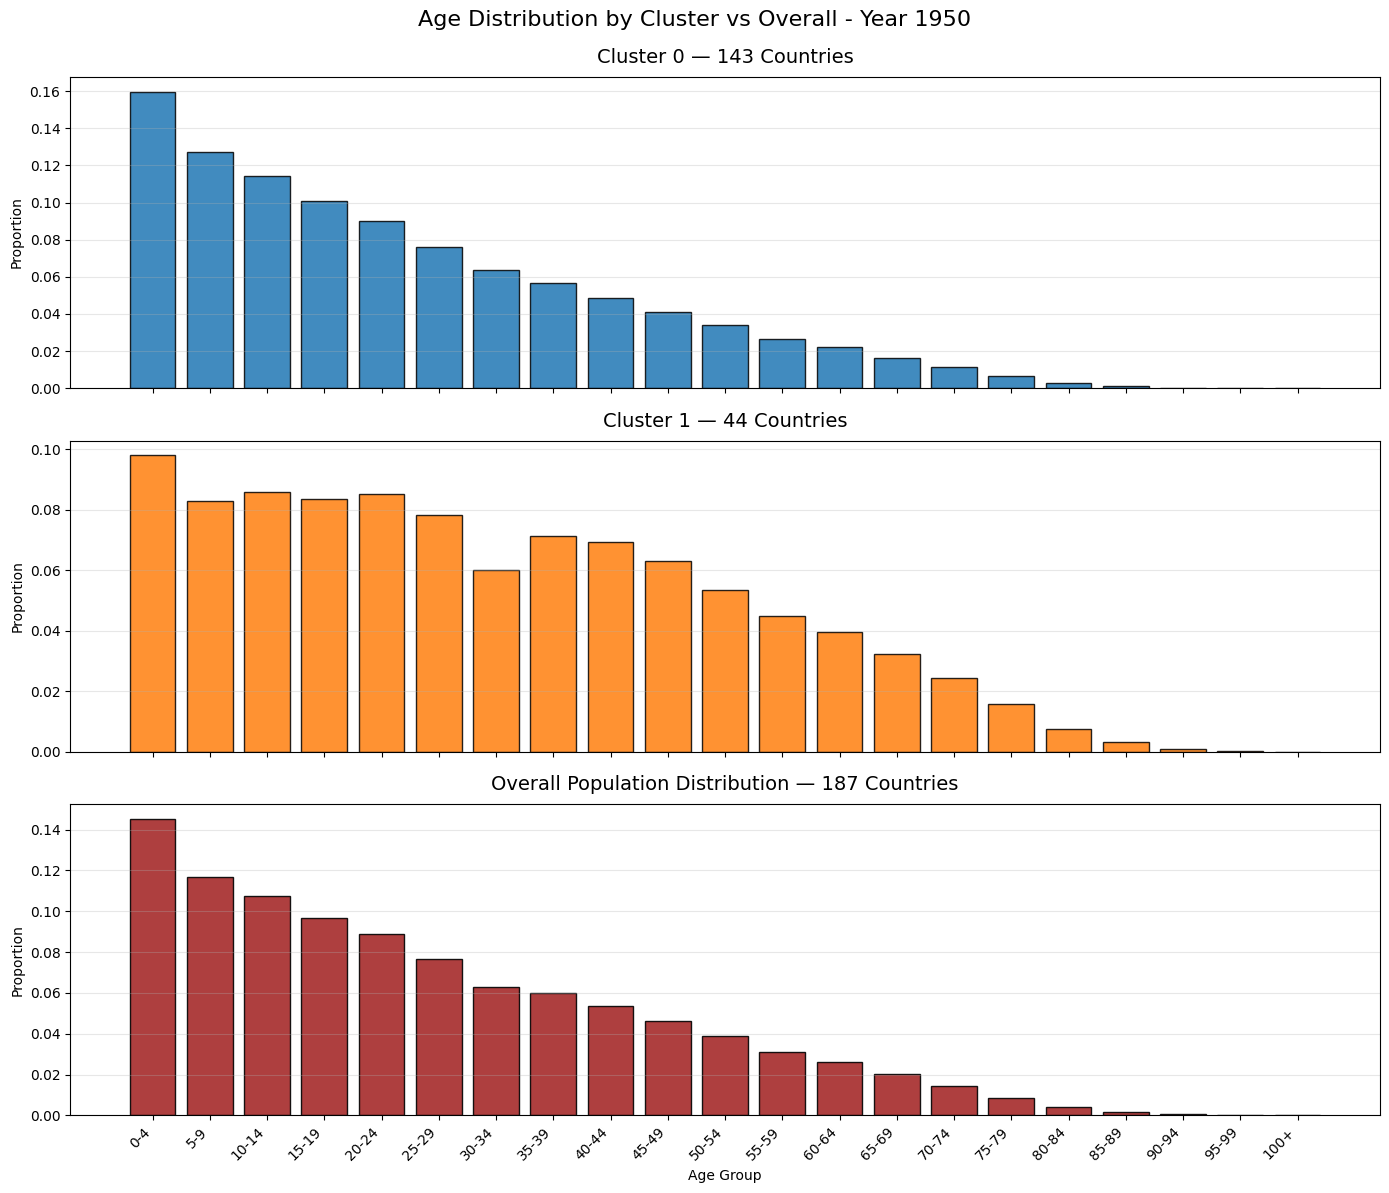


Generating separate plots for Year 1960...


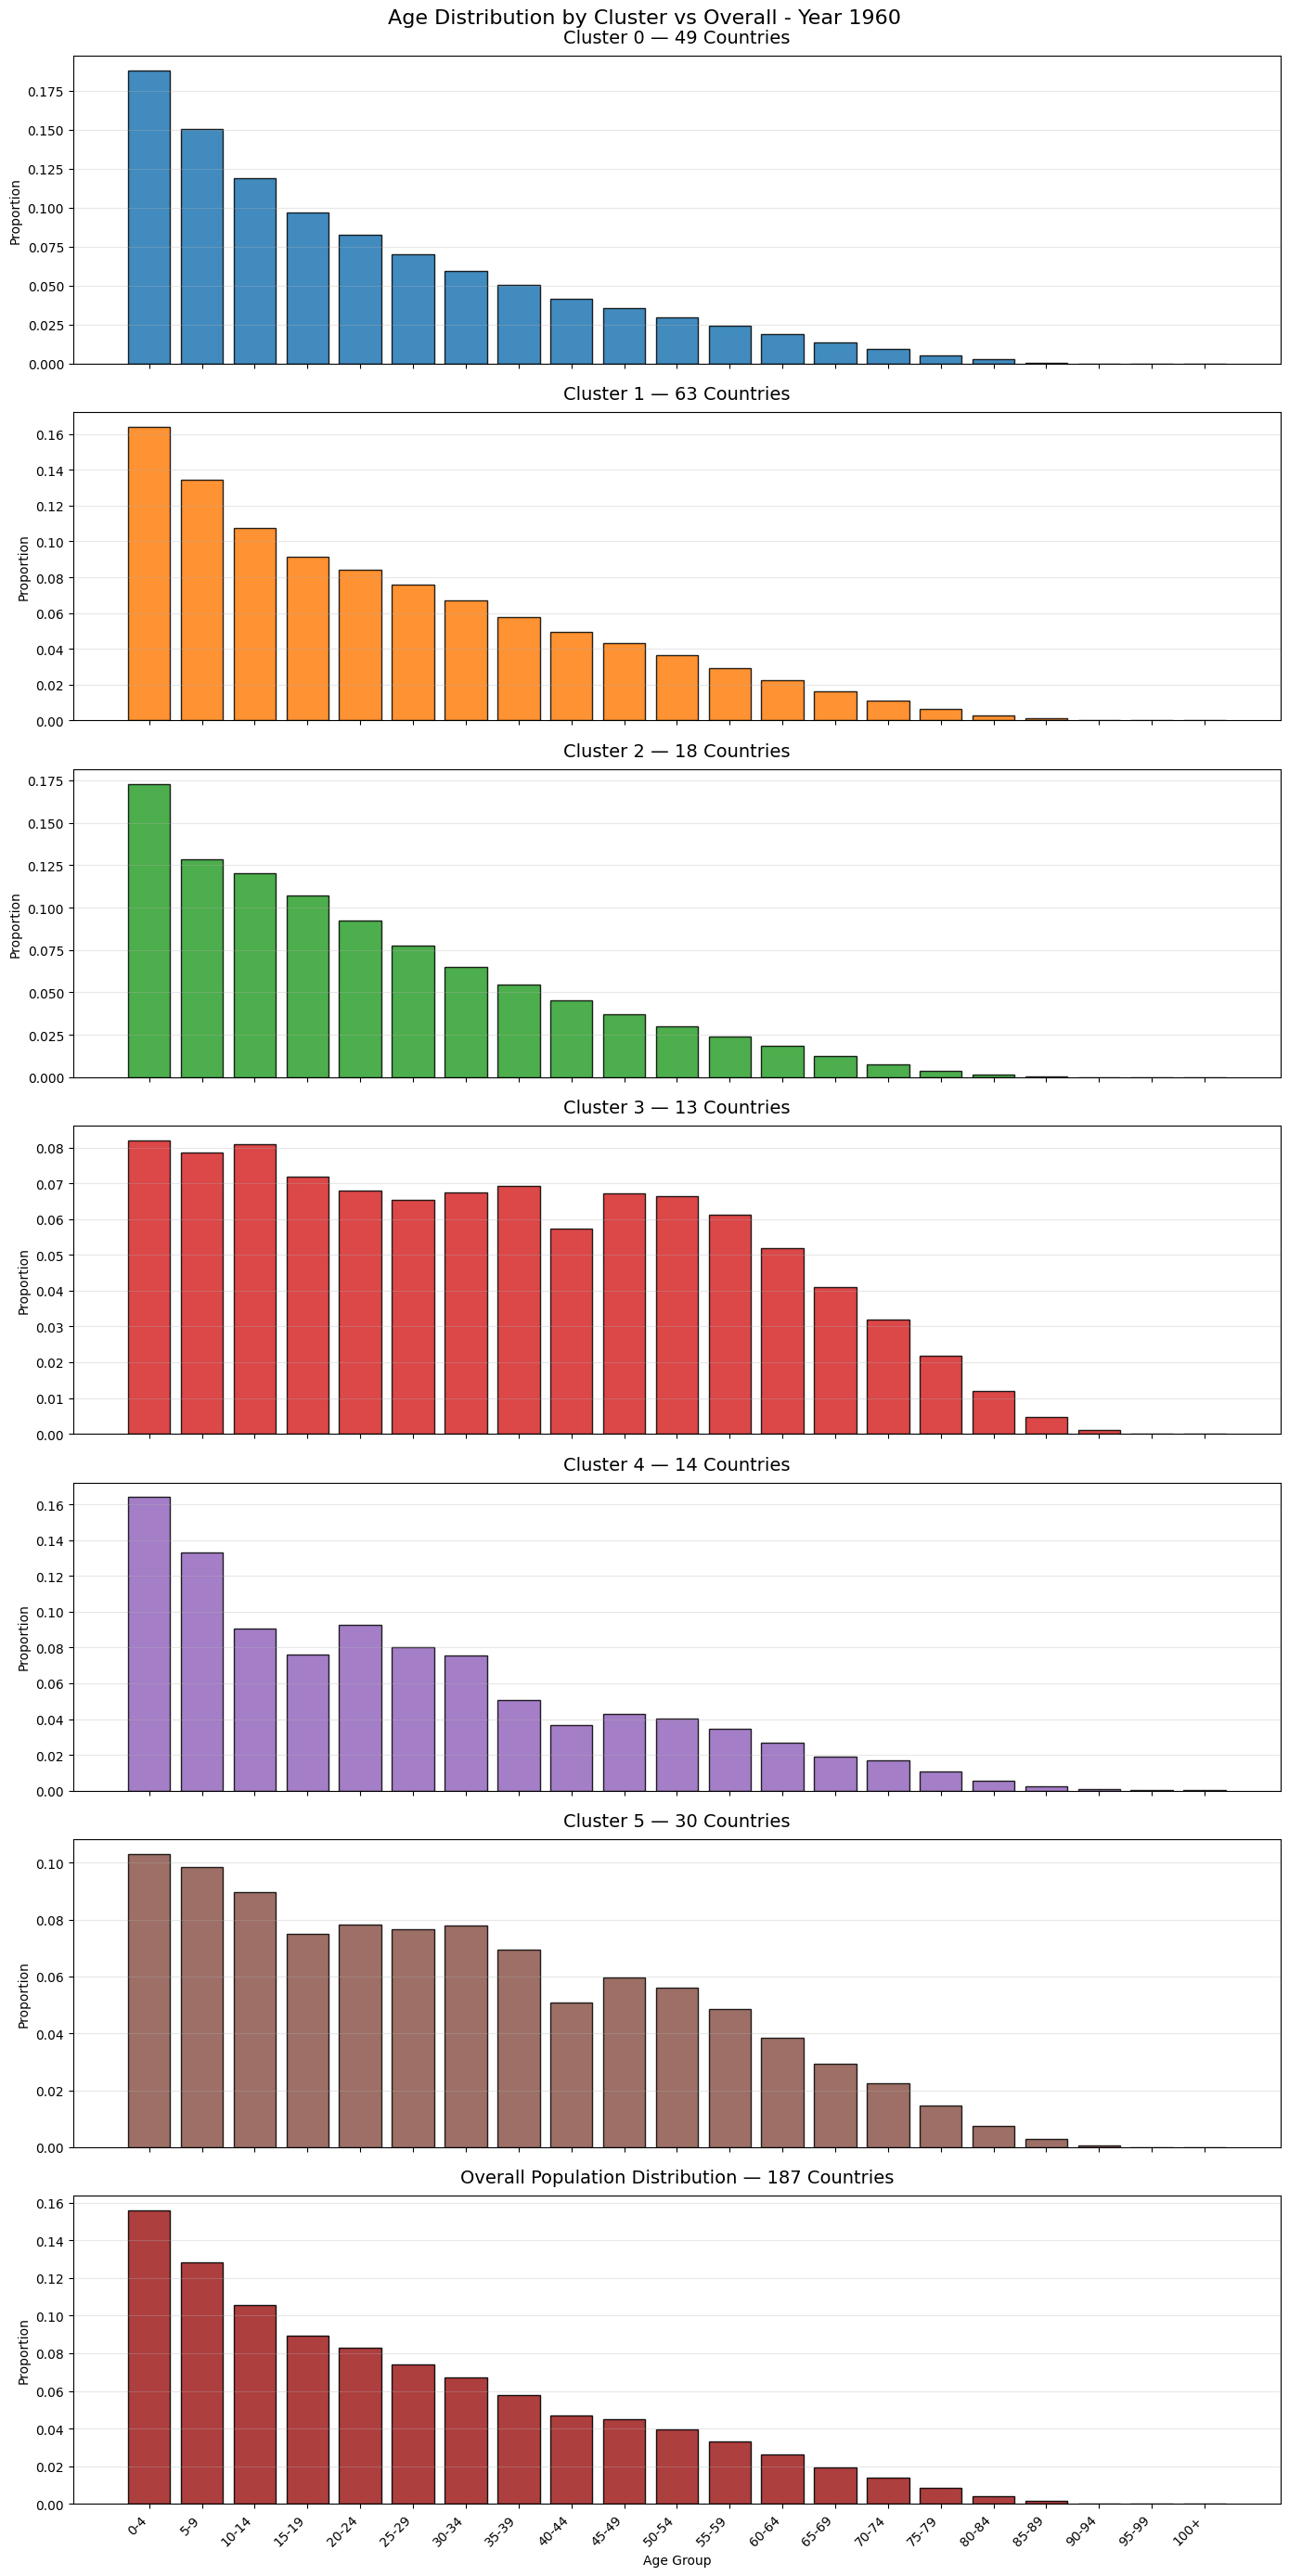


Generating separate plots for Year 1970...


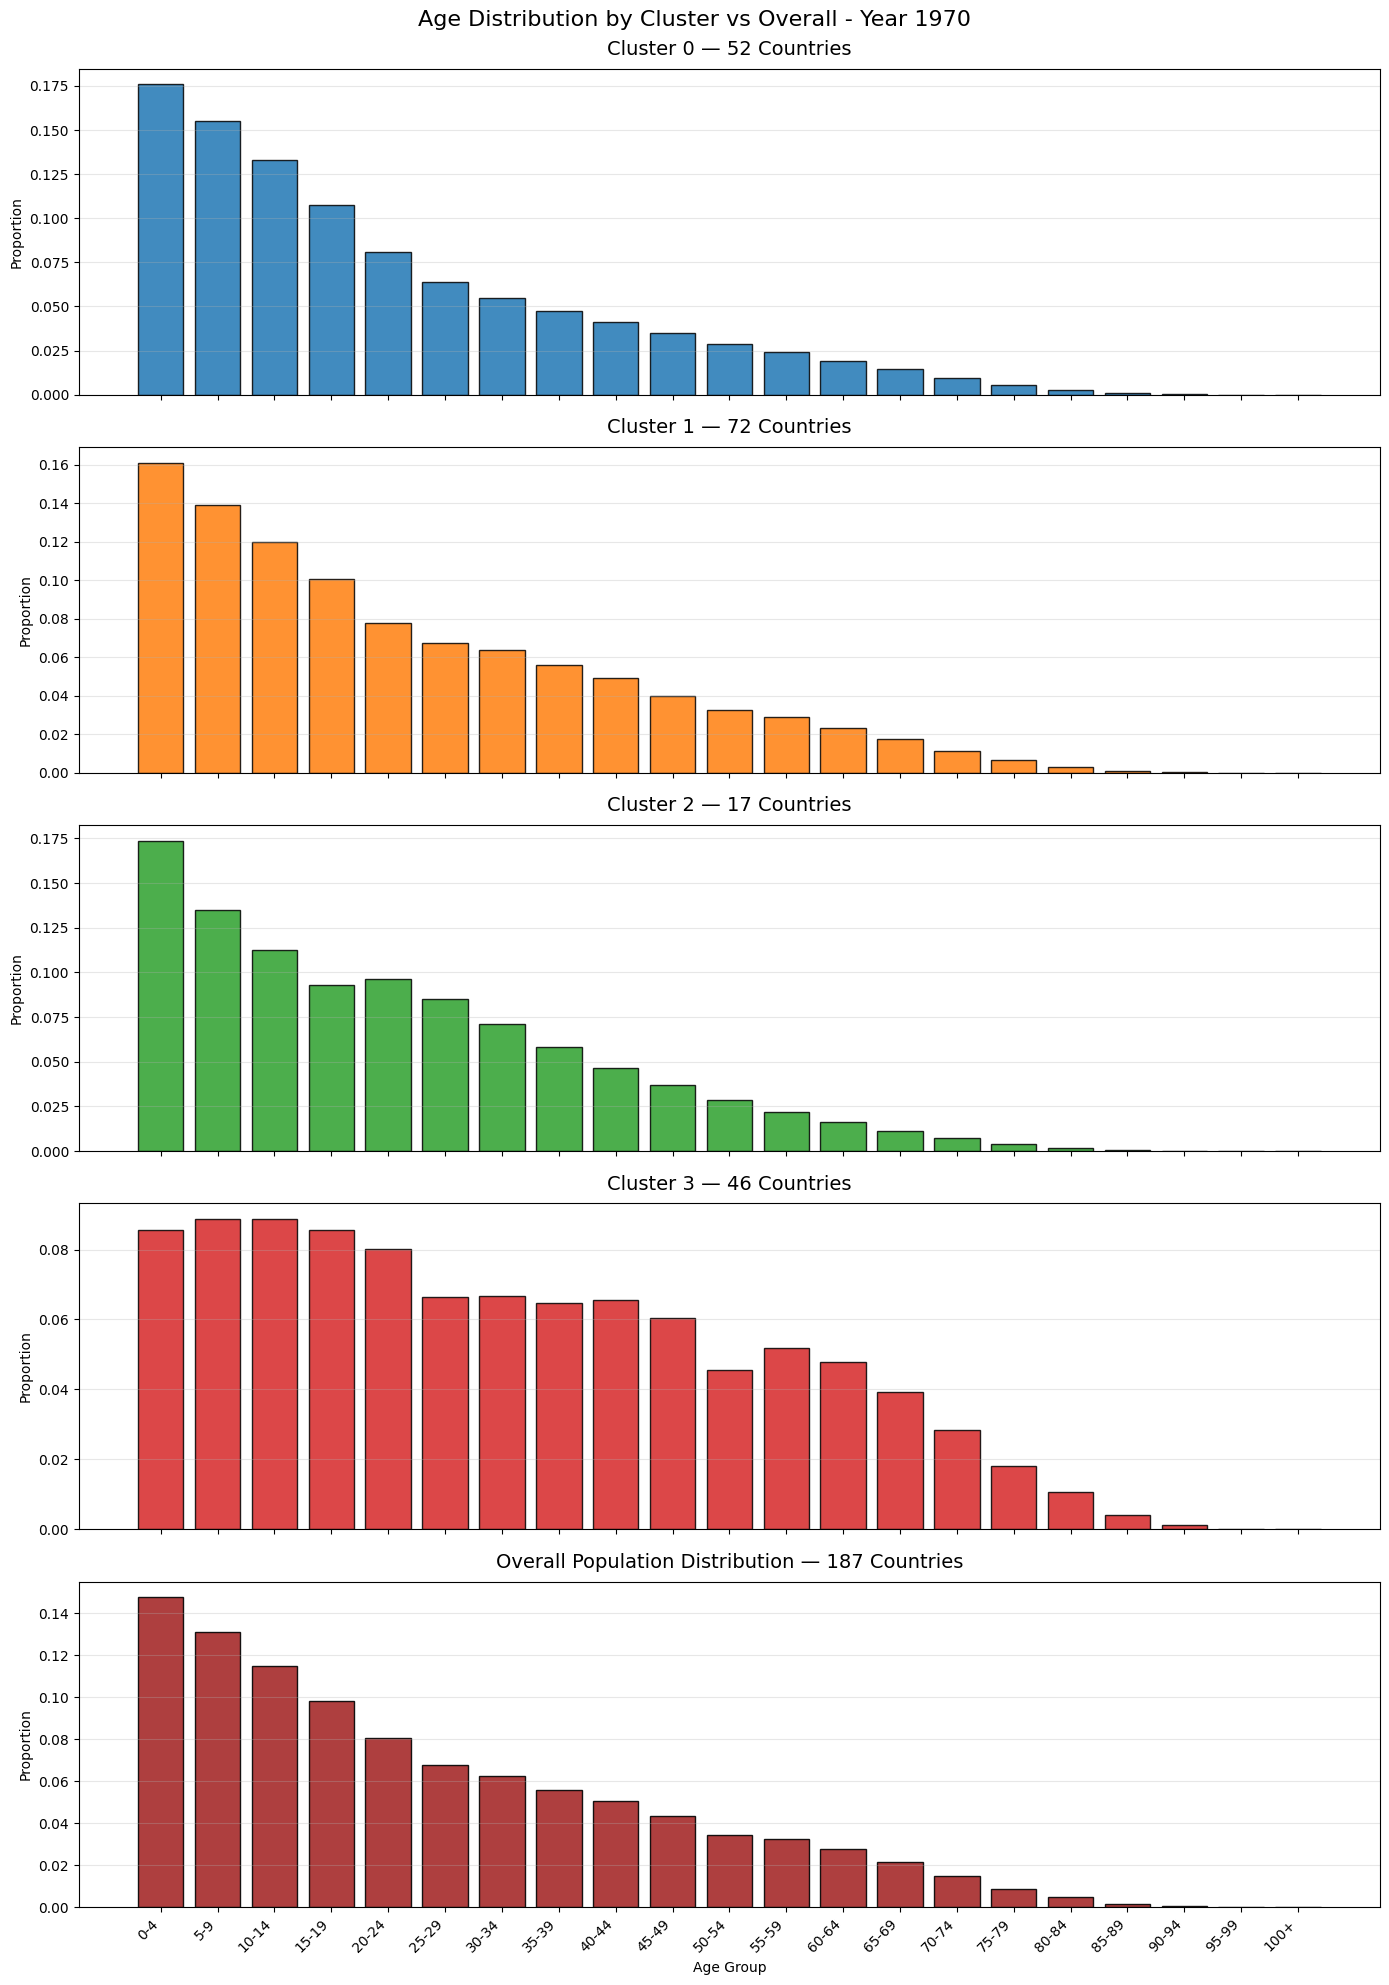


Generating separate plots for Year 1980...


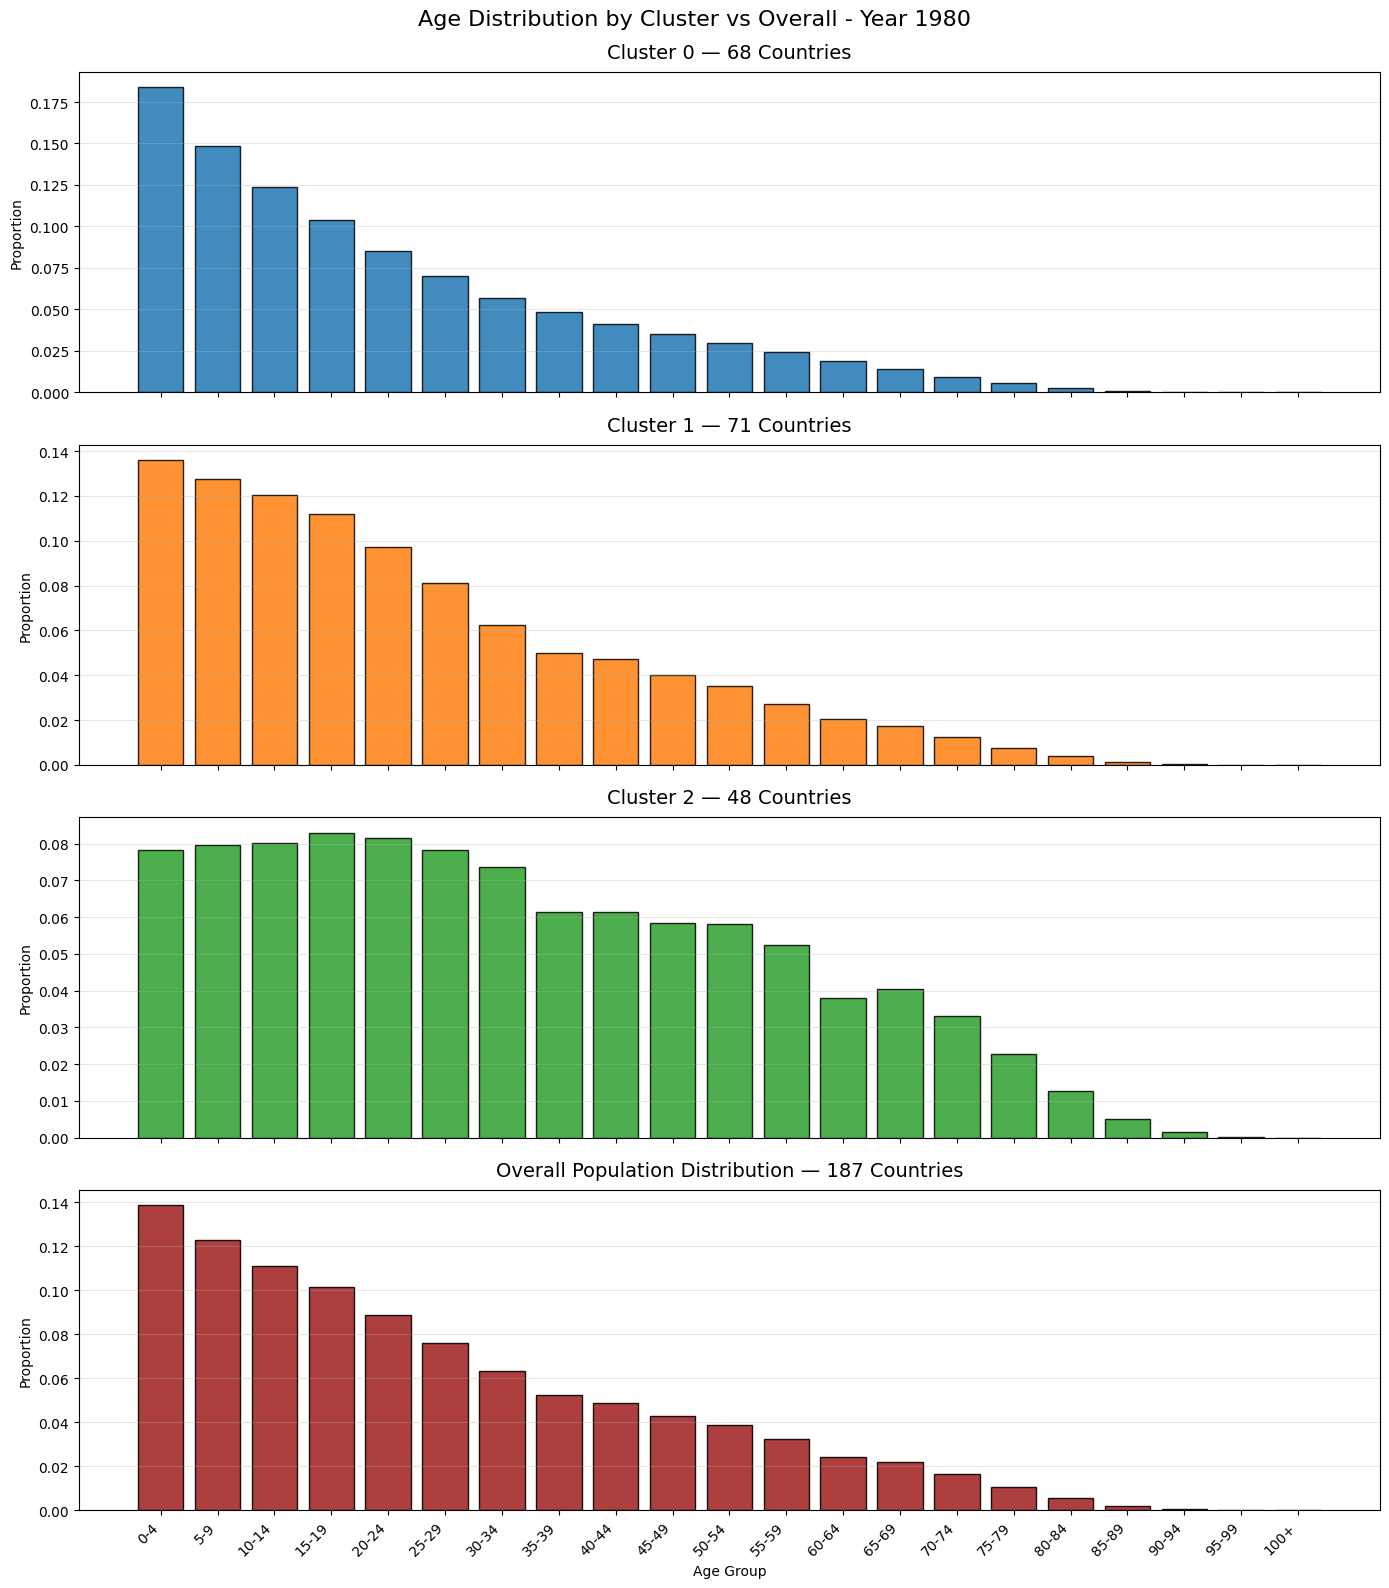


Generating separate plots for Year 2000...


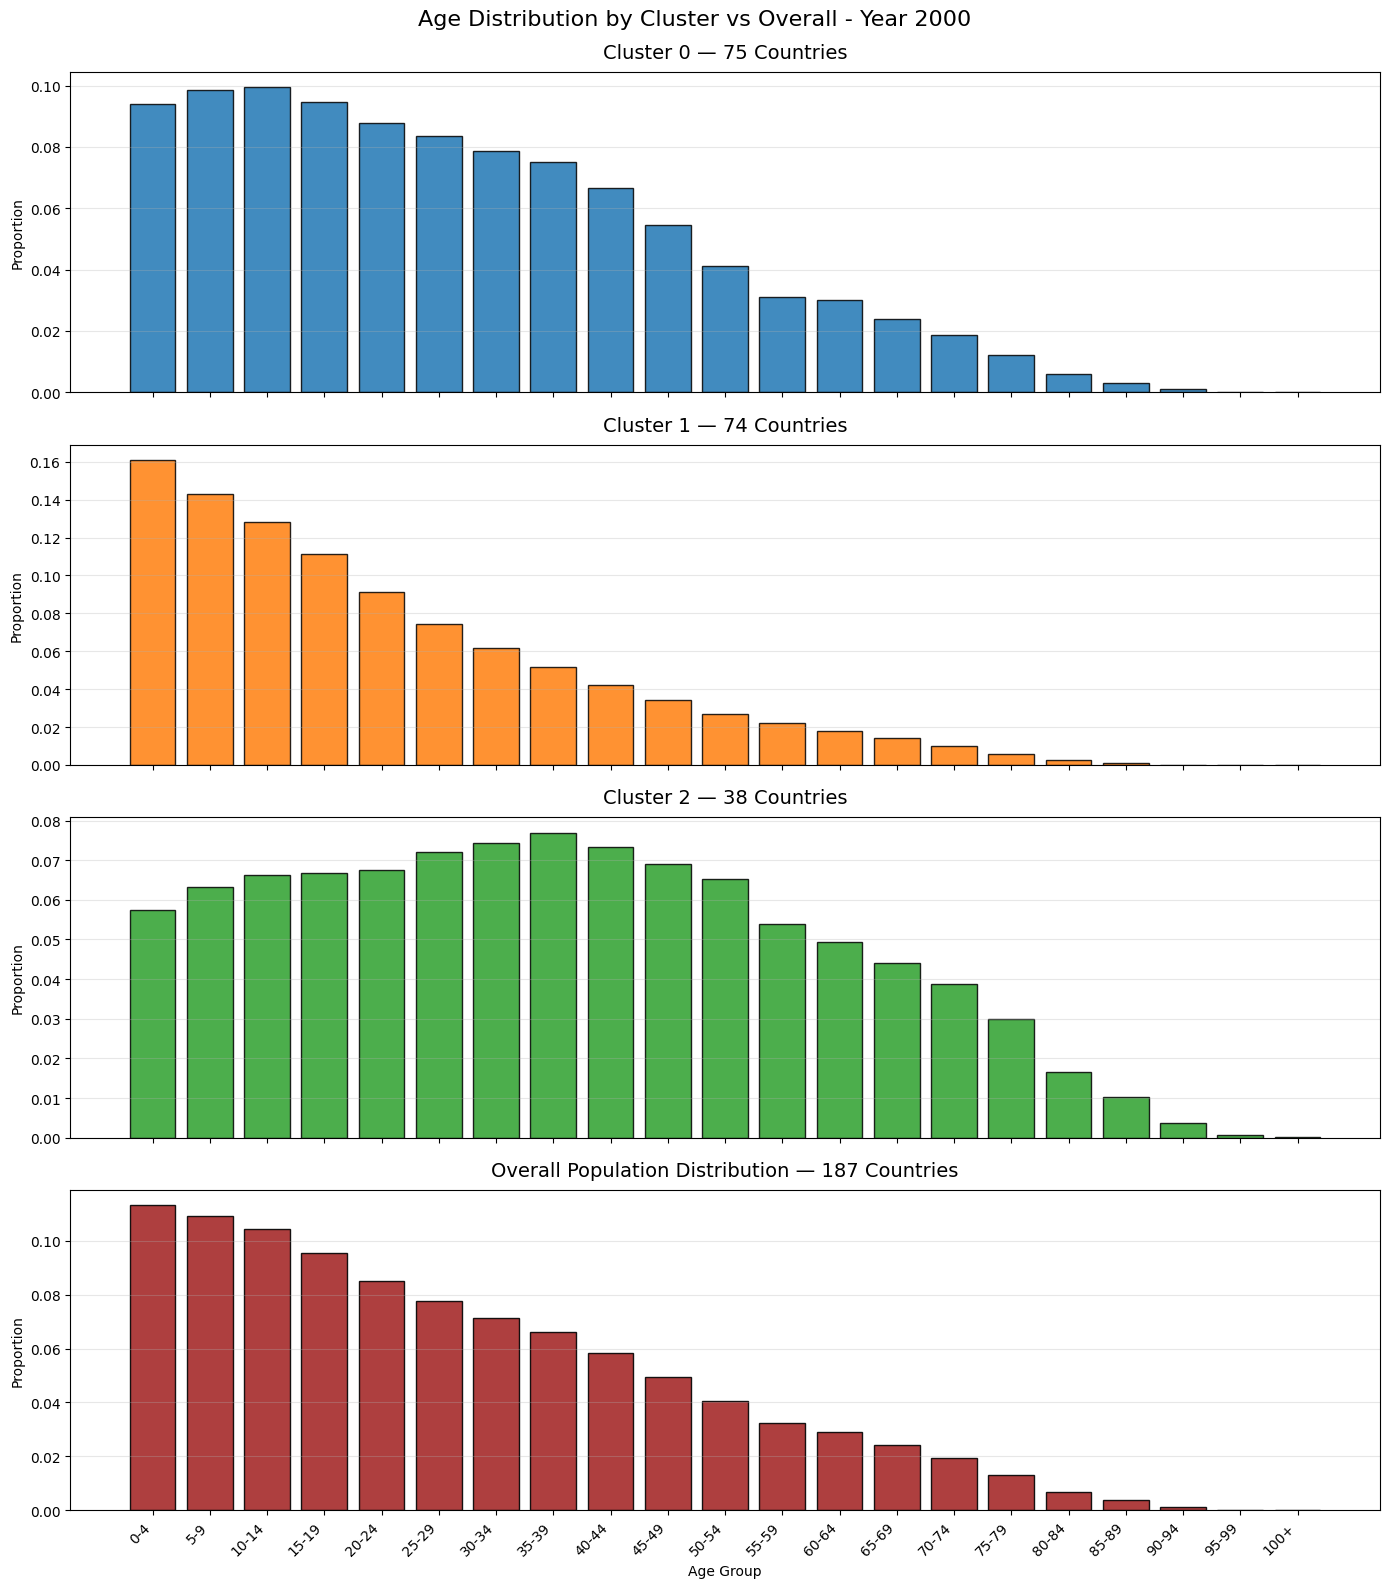


Generating separate plots for Year 2020...


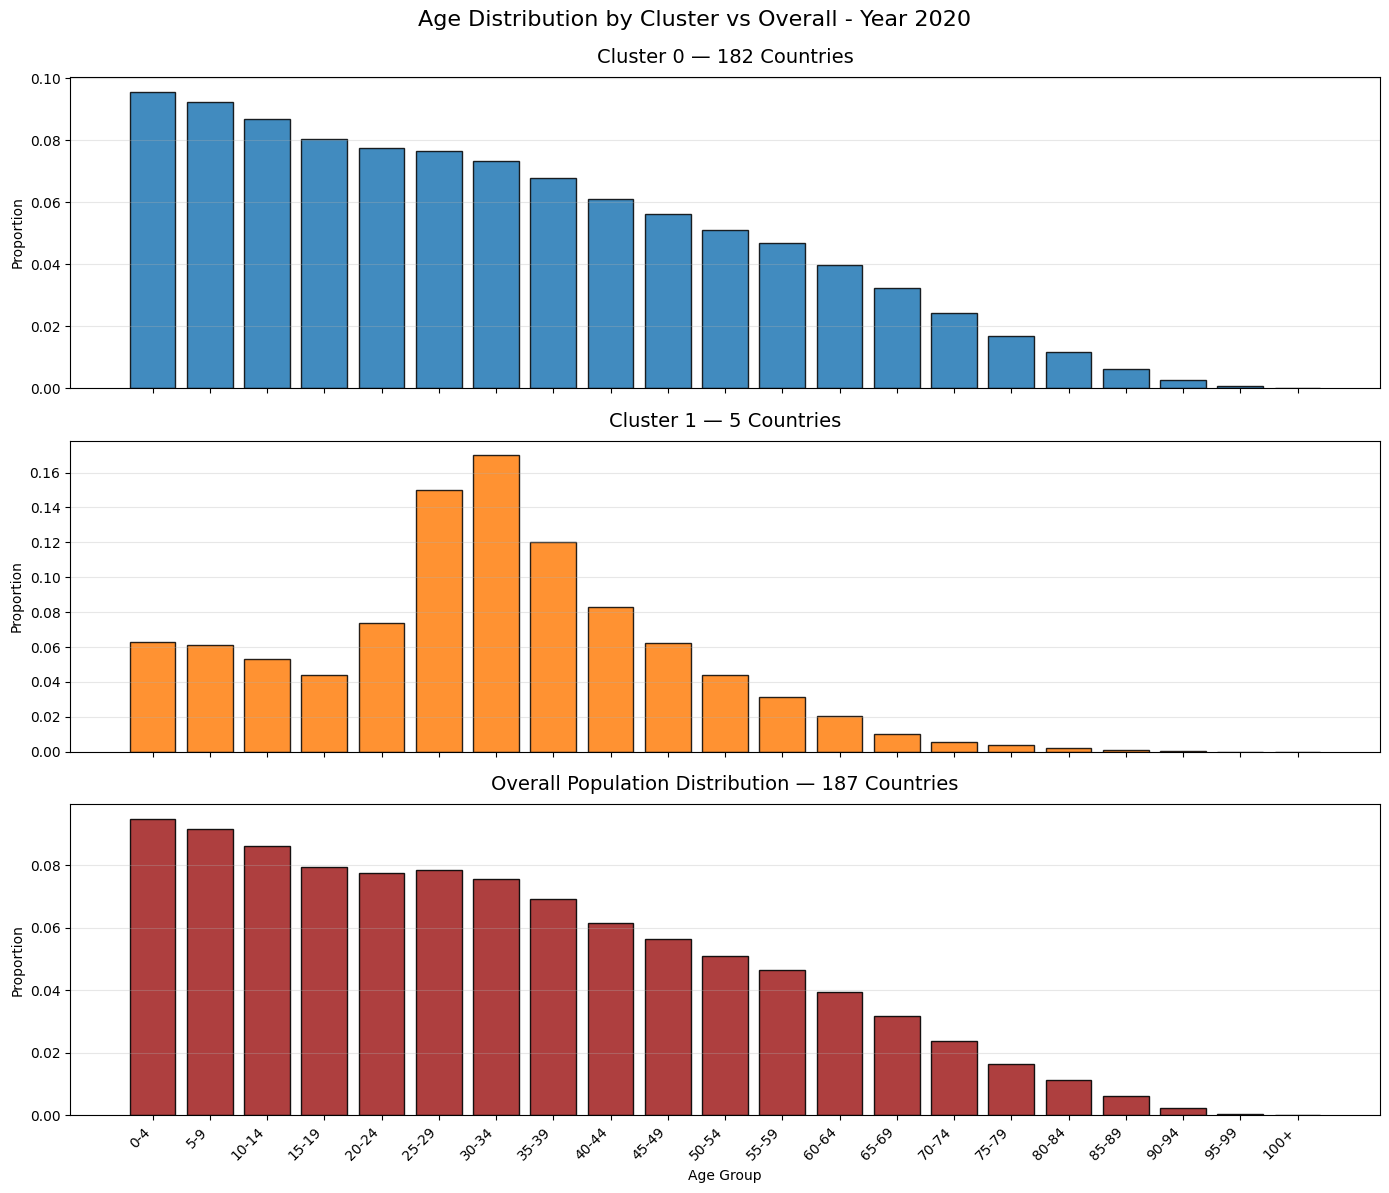


Generating separate plots for Year 2050...


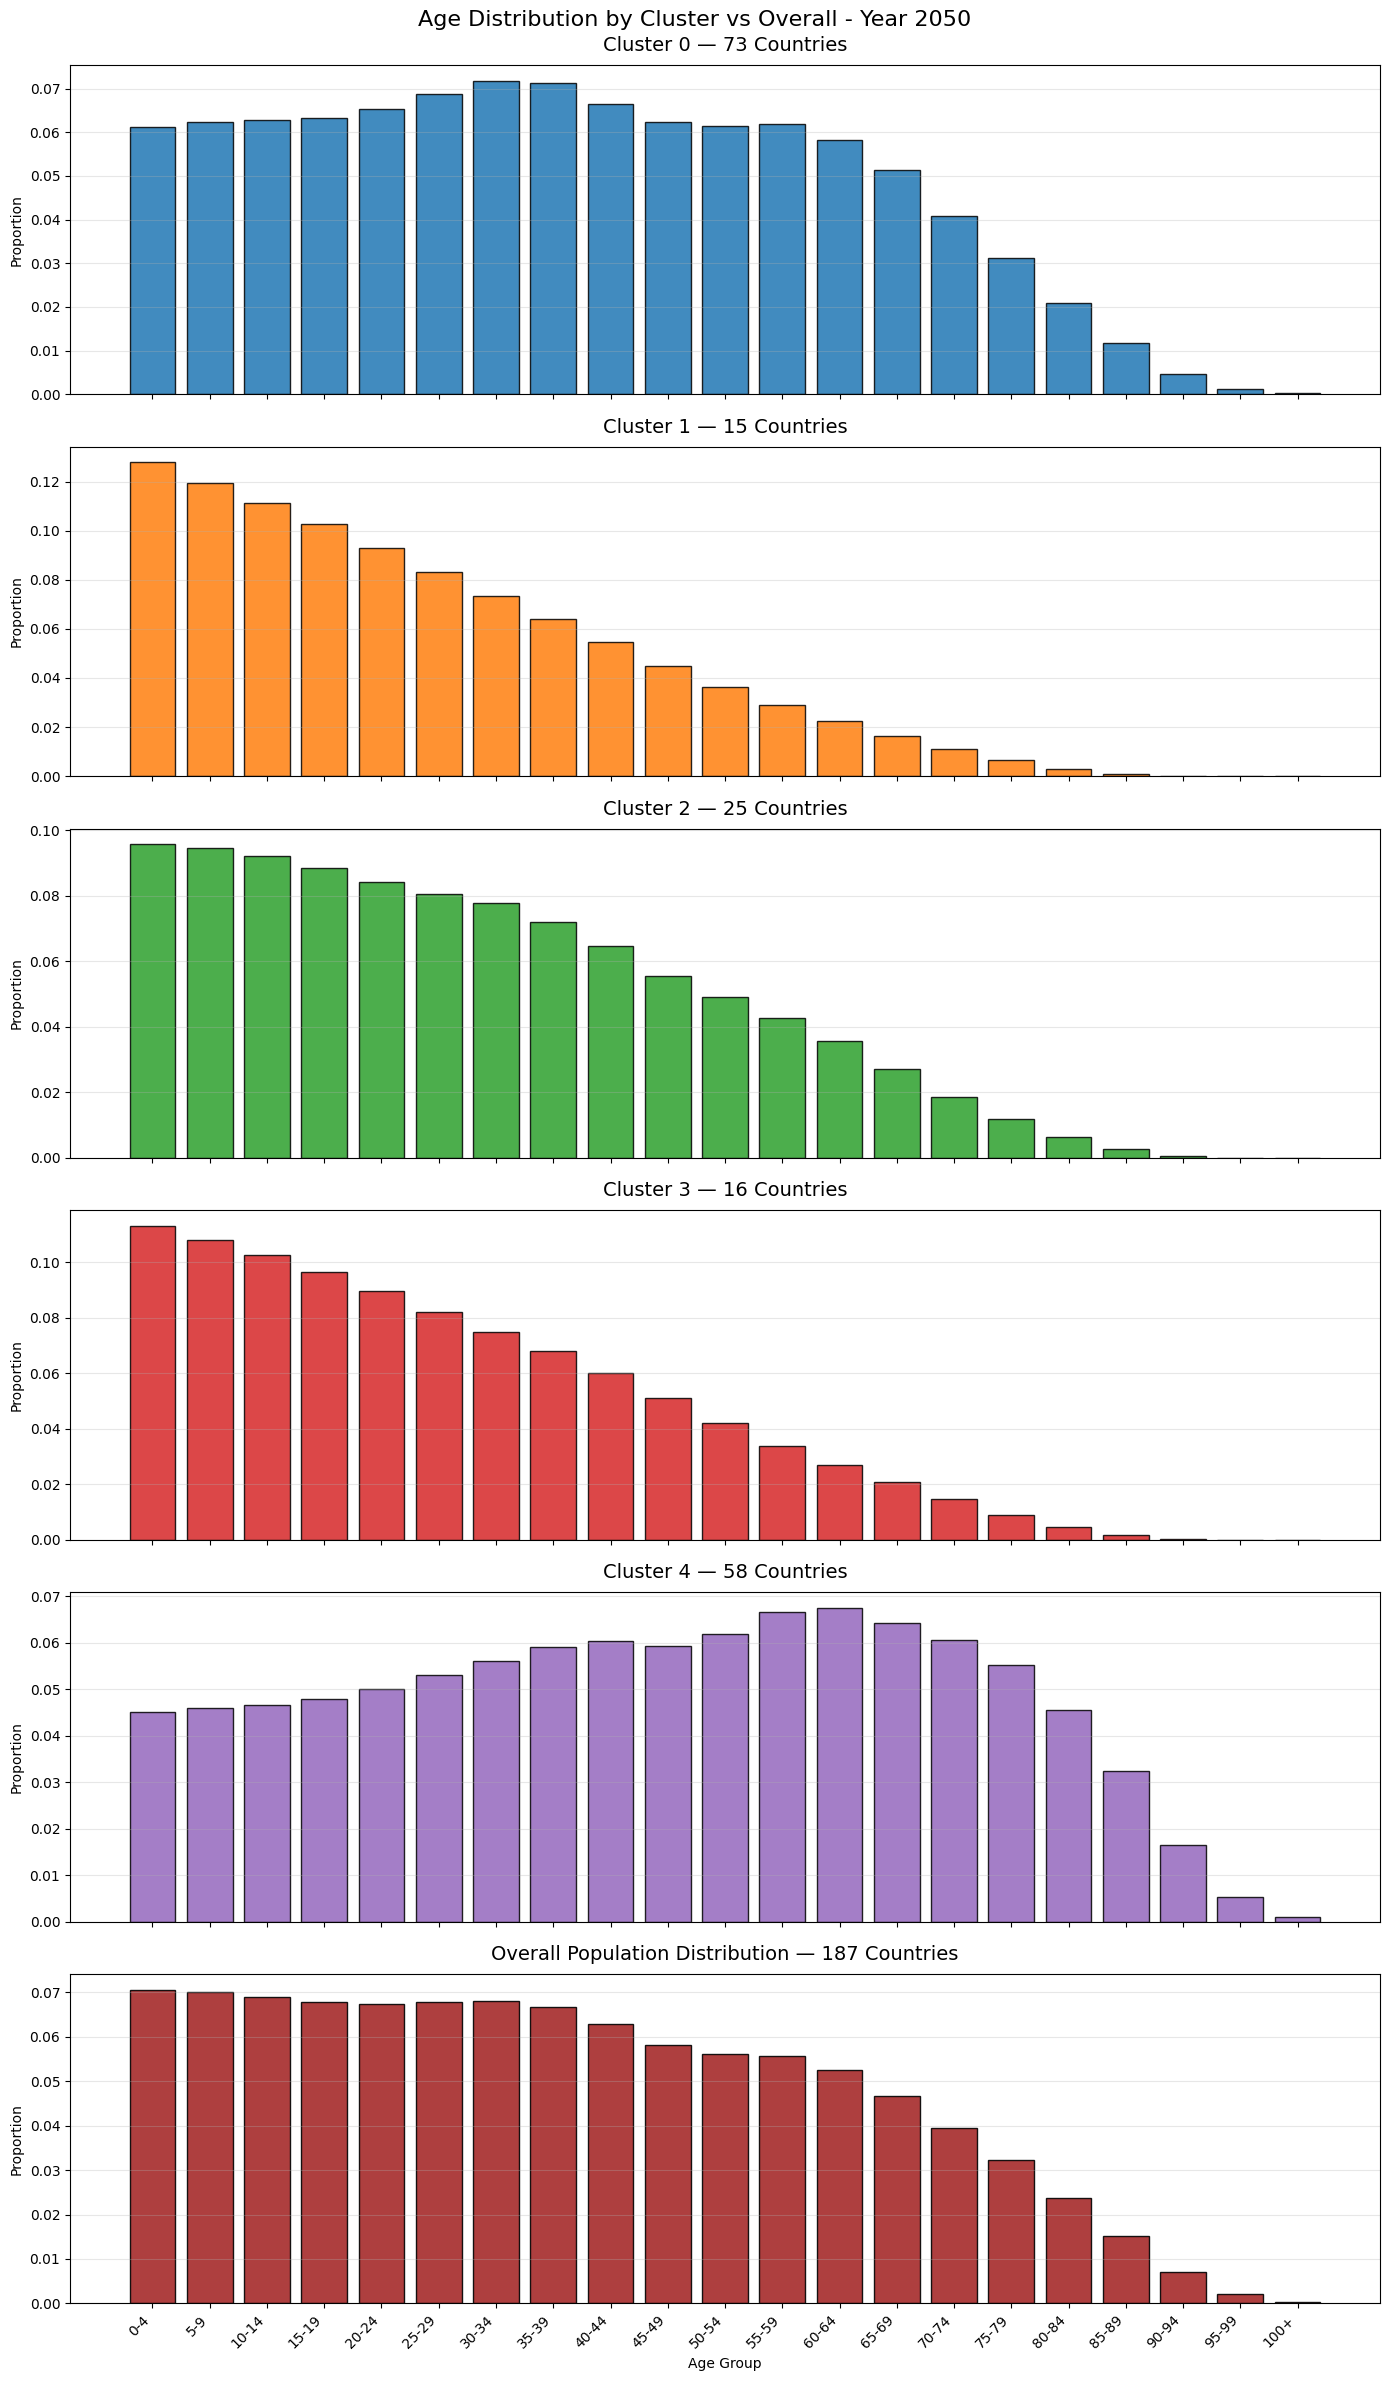


Generating separate plots for Year 2100...


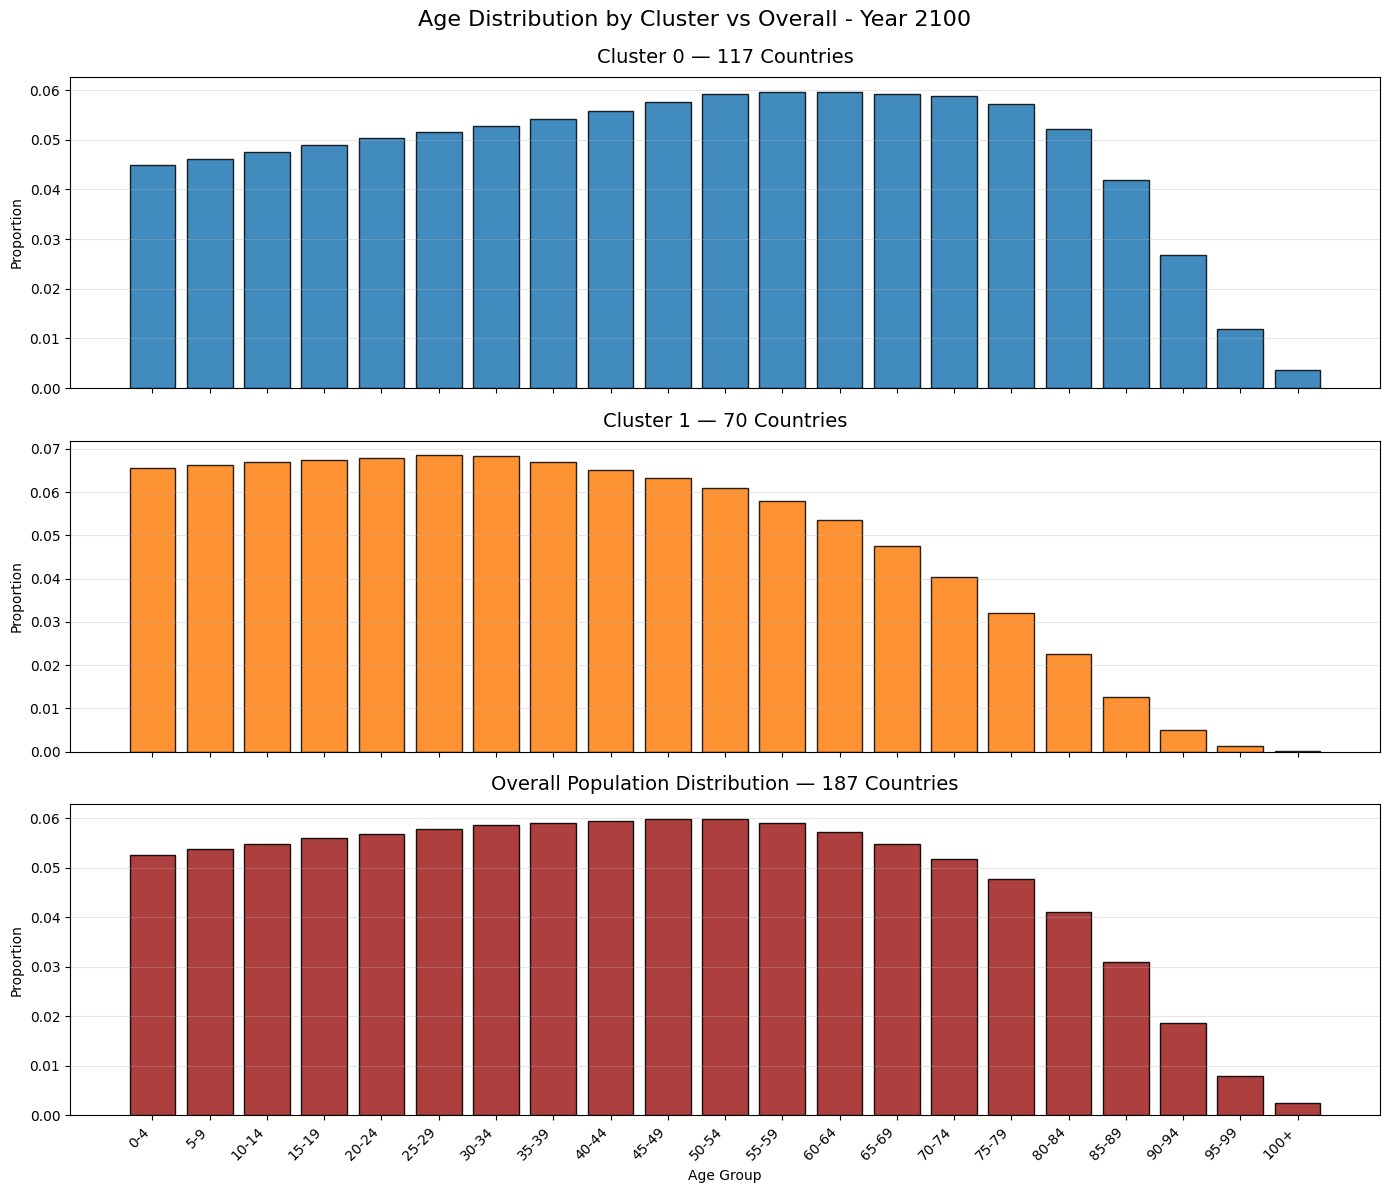


✅ All plots generated! Data saved to 'population_age_clusters_separate.csv'


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph
from scipy.sparse import csgraph
from scipy.sparse.linalg import eigsh
from sklearn.cluster import SpectralClustering

# ============================
# HELPER FUNCTIONS
# ============================
def extract_age_start(x):
    num = re.findall(r'\d+', str(x))
    return int(num[0]) if num else 999

def get_optimal_k(X_pca, max_k=6):
    if len(X_pca) < 4:
        return 3
    n_neighbors = min(5, len(X_pca) - 1)
    A = kneighbors_graph(X_pca, n_neighbors=n_neighbors, include_self=True)
    L = csgraph.laplacian(A, normed=True)

    k_compute = min(max_k + 2, len(X_pca) - 1)
    eigenvalues, _ = eigsh(L, k=k_compute, which='SM')
    eigenvalues = np.sort(eigenvalues)
    gaps = np.diff(eigenvalues)
    optimal_k = np.argmax(gaps) + 1
    return max(2, min(optimal_k, max_k))

# ============================
# MAIN CLUSTERING (Same as before)
# ============================
years_to_analyze = list(range(1950, 2101, 10))

all_results = []
age_cols = None

for year in years_to_analyze:
    df_year = df[df['Time'] == year].copy()
    if len(df_year) < 5:
        continue

    X = df_year.pivot_table(index='Location', columns='AgeGrp', values='PopTotal', fill_value=0)
    countries = X.index.tolist()

    if age_cols is None:
        age_cols = sorted(X.columns.tolist(), key=extract_age_start)

    X_pct = X.div(X.sum(axis=1).replace(0, 1), axis=0)

    X_scaled = StandardScaler().fit_transform(X_pct)
    pca = PCA(n_components=0.95, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    k = get_optimal_k(X_pca, max_k=6)

    clustering = SpectralClustering(
        n_clusters=k,
        affinity='nearest_neighbors',
        n_neighbors=5,
        random_state=42,
        assign_labels='kmeans'
    )
    labels = clustering.fit_predict(X_pca)

    X_pct = X_pct.copy()
    X_pct['Cluster'] = labels

    overall_mean = X_pct.drop(columns=['Cluster']).mean()

    for c in range(k):
        cluster_mean = X_pct[X_pct['Cluster'] == c].drop(columns=['Cluster']).mean()
        num_countries = (X_pct['Cluster'] == c).sum()

        row = {'Year': year, 'Cluster': c, 'Num_Countries': num_countries, 'Type': 'Cluster'}
        for ag in age_cols:
            row[ag] = cluster_mean[ag]
        all_results.append(row)

    overall_row = {'Year': year, 'Cluster': 'Overall', 'Num_Countries': len(X_pct), 'Type': 'Overall'}
    for ag in age_cols:
        overall_row[ag] = overall_mean[ag]
    all_results.append(overall_row)

result_df = pd.DataFrame(all_results)

# ============================
# SEPARATE PLOTS FOR EASY COMPARISON
# ============================
def plot_separate_distributions(year):
    df_plot = result_df[result_df['Year'] == year]
    if df_plot.empty:
        print(f"No data for year {year}")
        return

    clusters = df_plot[df_plot['Type'] == 'Cluster']
    n_clusters = len(clusters)
    total_plots = n_clusters + 1  # + Overall

    fig, axes = plt.subplots(total_plots, 1, figsize=(14, 4 * total_plots), sharex=True)
    if total_plots == 1:
        axes = [axes]

    # Plot each cluster separately
    for i, (_, row) in enumerate(clusters.iterrows()):
        ax = axes[i]
        values = [row[ag] for ag in age_cols]

        ax.bar(age_cols, values, color=plt.cm.tab10(i % 10), alpha=0.85, edgecolor='black')
        ax.set_title(f"Cluster {int(row['Cluster'])} — {int(row['Num_Countries'])} Countries",
                    fontsize=14, pad=10)
        ax.set_ylabel("Proportion")
        ax.grid(axis='y', alpha=0.3)

    # Plot Overall at the bottom
    overall_row = df_plot[df_plot['Type'] == 'Overall'].iloc[0]
    ax = axes[-1]
    values = [overall_row[ag] for ag in age_cols]

    ax.bar(age_cols, values, color='brown', alpha=0.9, edgecolor='black')
    ax.set_title(f"Overall Population Distribution — {int(overall_row['Num_Countries'])} Countries",
                fontsize=14, pad=10)
    ax.set_ylabel("Proportion")
    ax.set_xlabel("Age Group")
    ax.grid(axis='y', alpha=0.3)

    plt.xticks(rotation=45, ha='right')
    fig.suptitle(f"Age Distribution by Cluster vs Overall - Year {year}", fontsize=16, y=0.99)
    plt.tight_layout()
    plt.show()

# ============================
# GENERATE PLOTS FOR SELECTED YEARS
# ============================
plot_years = [1950, 1960, 1970, 1980, 2000, 2020, 2050, 2100]

for year in plot_years:
    print(f"\nGenerating separate plots for Year {year}...")
    plot_separate_distributions(year)

# Save data
result_df.to_csv('population_age_clusters_separate.csv', index=False)
print("\n✅ All plots generated! Data saved to 'population_age_clusters_separate.csv'")

#Demo for spec - 1950-2100

<>:9: SyntaxWarning:

invalid escape sequence '\d'

<>:9: SyntaxWarning:

invalid escape sequence '\d'

/tmp/ipykernel_20367/3716569995.py:9: SyntaxWarning:

invalid escape sequence '\d'

/tmp/ipykernel_20367/3716569995.py:49: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_20367/3716569995.py:49: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_20367/3716569995.py:49: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_20367/3716569995.py:49: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_20367/3716569995.py:49: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_t

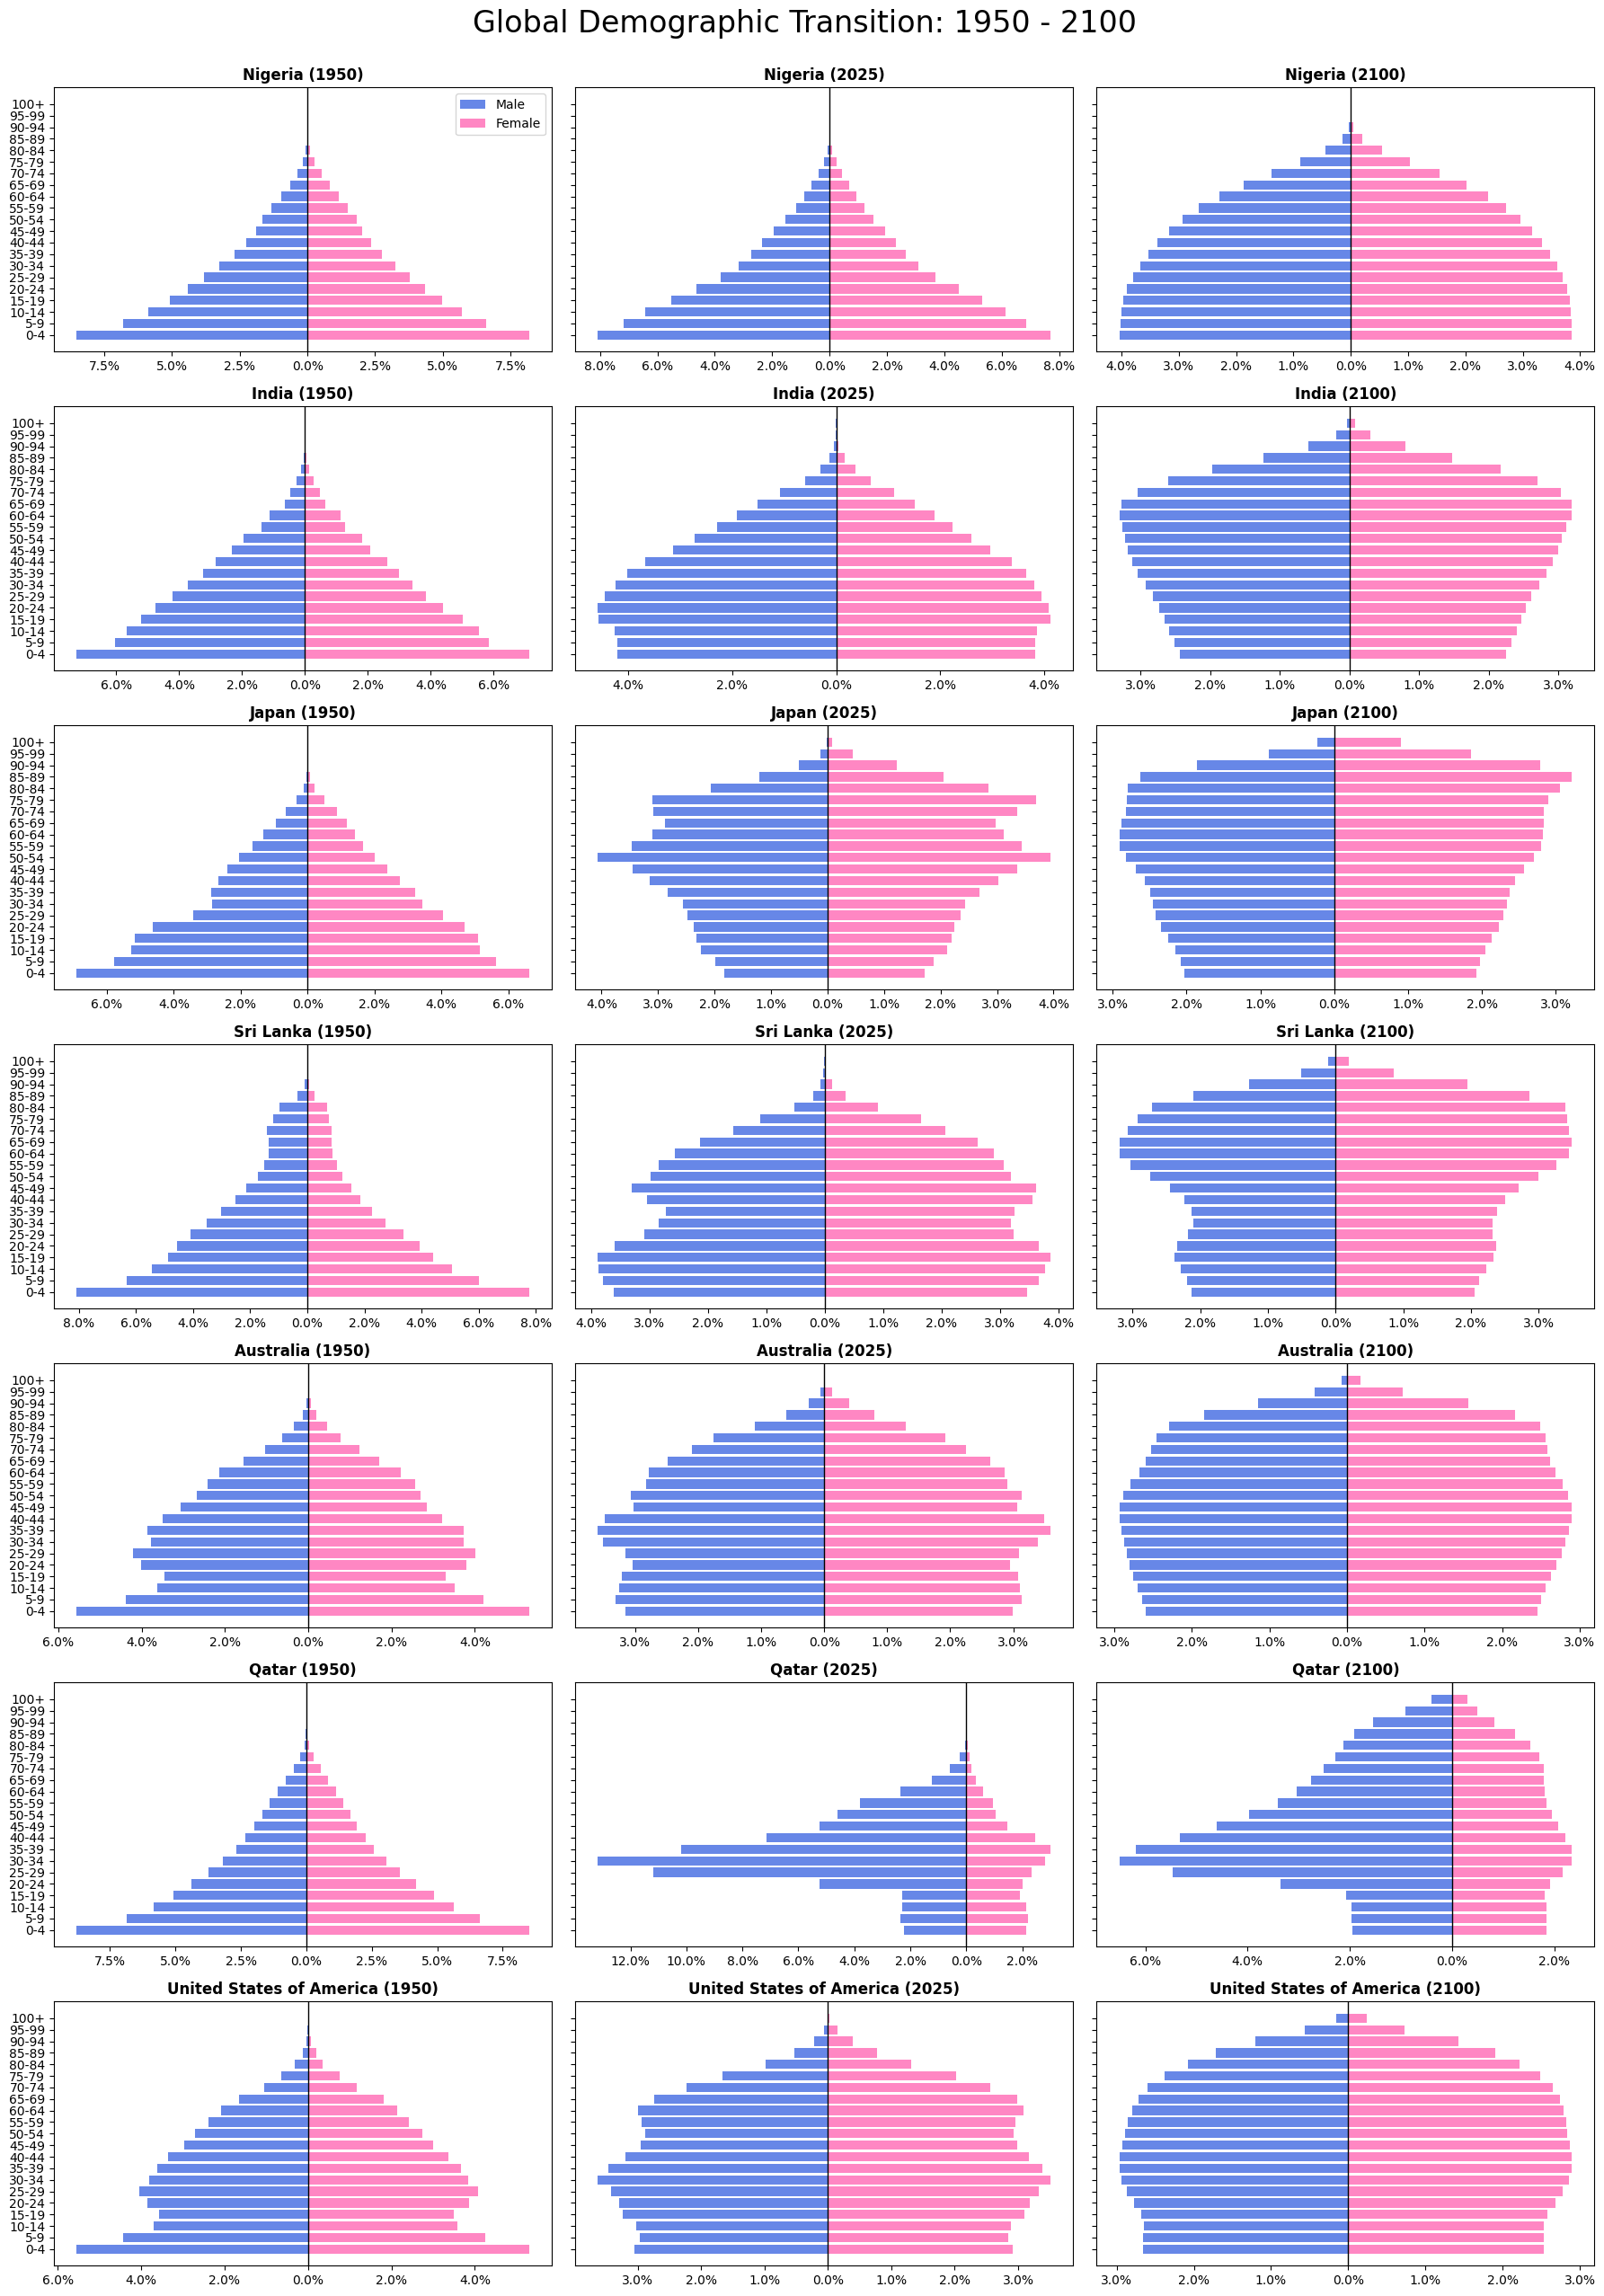

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load and Setup Sorting Helper
df = pd.read_csv('age_data_1.csv')

# This extracts numbers so "5-9" comes before "10-14"
df['age_sort'] = df['AgeGrp'].str.extract('(\d+)').astype(float)

# 2. Setup Countries and Years
target_countries = ['Nigeria', 'India', 'Japan', 'Sri Lanka', 'Australia', 'Qatar', 'United States of America']
target_years = [1950, 2025, 2100]

# 3. Create the Visualization Grid
fig, axes = plt.subplots(len(target_countries), len(target_years),
                         figsize=(18, 25), sharey=True)

for i, country in enumerate(target_countries):
    for j, year in enumerate(target_years):
        ax = axes[i, j]

        # Filter and SORT correctly
        data = df[(df['Location'] == country) & (df['Time'] == year)].sort_values('age_sort')

        if data.empty:
            ax.text(0.5, 0.5, f"No Data for {year}", ha='center')
            continue

        ages = data['AgeGrp']
        male_pop = data['PopMale']
        female_pop = data['PopFemale']

        # Calculate percentage for accurate shape comparison
        total = male_pop.sum() + female_pop.sum()
        m_pct = (male_pop / total) * 100
        f_pct = (female_pop / total) * 100

        # Plotting
        ax.barh(ages, -m_pct, color='royalblue', label='Male', alpha=0.8)
        ax.barh(ages, f_pct, color='hotpink', label='Female', alpha=0.8)
        ax.axvline(0, color='black', linewidth=1)

        # Formatting
        ax.set_title(f"{country} ({year})", fontsize=12, fontweight='bold')

        # Absolute value labels for X-axis
        ticks = ax.get_xticks()
        ax.set_xticklabels([f"{abs(x):.1f}%" for x in ticks])

        if i == 0 and j == 0:
            ax.legend()

plt.tight_layout()
plt.suptitle("Global Demographic Transition: 1950 - 2100", fontsize=24, y=1.02)
plt.show()


No of Hier clusters  for 1950-2100

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# --- Parameters ---
max_clusters = 10  # Maximum clusters to test
target_column_for_youth = '0-4'  # Column representing youngest age group

# --- Prepare summary list ---
hierarchical_summary = []

years = sorted(df['Time'].unique())

for year in years:
    # 1. Pivot data for the year
    X_year = df[df['Time'] == year].pivot_table(index='Location', columns='AgeGrp', values='PopTotal').fillna(0)

    # Avoid division by zero
    X_year_pct = X_year.div(X_year.sum(axis=1).replace(0,1), axis=0)

    # 2. Standardize and PCA
    X_scaled = StandardScaler().fit_transform(X_year_pct)
    X_pca = PCA(n_components=0.95).fit_transform(X_scaled)

    # 3. Fit hierarchical clustering for multiple cluster numbers to find "optimal"
    # We'll use the youth age group to rank clusters by "youthfulness"
    cluster_results = []
    for k in range(2, min(max_clusters+1, X_pca.shape[0])):  # min ensures n_samples limit
        hc = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
        labels = hc.fit_predict(X_pca)

        # Calculate average youth percentage per cluster
        youth_per_cluster = X_year_pct.groupby(labels)[target_column_for_youth].mean()

        # Define a "score" to measure separation: max difference in youth %
        score = youth_per_cluster.max() - youth_per_cluster.min()
        cluster_results.append((k, score))

    # Select k with maximum separation in youth percentage
    optimal_k, _ = max(cluster_results, key=lambda x: x[1])

    # Fit final hierarchical clustering with optimal_k
    hc_final = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
    final_labels = hc_final.fit_predict(X_pca)

    # Save summary
    hierarchical_summary.append({
        'Year': year,
        'Optimal_HC_k': optimal_k,
        'Cluster_Labels': final_labels
    })

# Convert to DataFrame
hierarchical_df = pd.DataFrame(hierarchical_summary)
print(hierarchical_df[['Year', 'Optimal_HC_k']])

# Optional: save to CSV for your report
hierarchical_df.to_csv('hierarchical_optimal_clusters_1950_2100.csv', index=False)
print("\nSaved optimal hierarchical clusters per year to 'hierarchical_optimal_clusters_1950_2100.csv'")

     Year  Optimal_HC_k
0    1950            10
1    1951             7
2    1952             8
3    1953             6
4    1954             7
..    ...           ...
146  2096             8
147  2097            10
148  2098             8
149  2099             9
150  2100             9

[151 rows x 2 columns]

Saved optimal hierarchical clusters per year to 'hierarchical_optimal_clusters_1950_2100.csv'


Demo using Hier for 1950-2100

<>:10: SyntaxWarning:

invalid escape sequence '\d'

<>:10: SyntaxWarning:

invalid escape sequence '\d'

/tmp/ipykernel_20367/1443579009.py:10: SyntaxWarning:

invalid escape sequence '\d'

/tmp/ipykernel_20367/1443579009.py:65: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_20367/1443579009.py:65: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_20367/1443579009.py:65: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_20367/1443579009.py:65: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_20367/1443579009.py:65: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after se

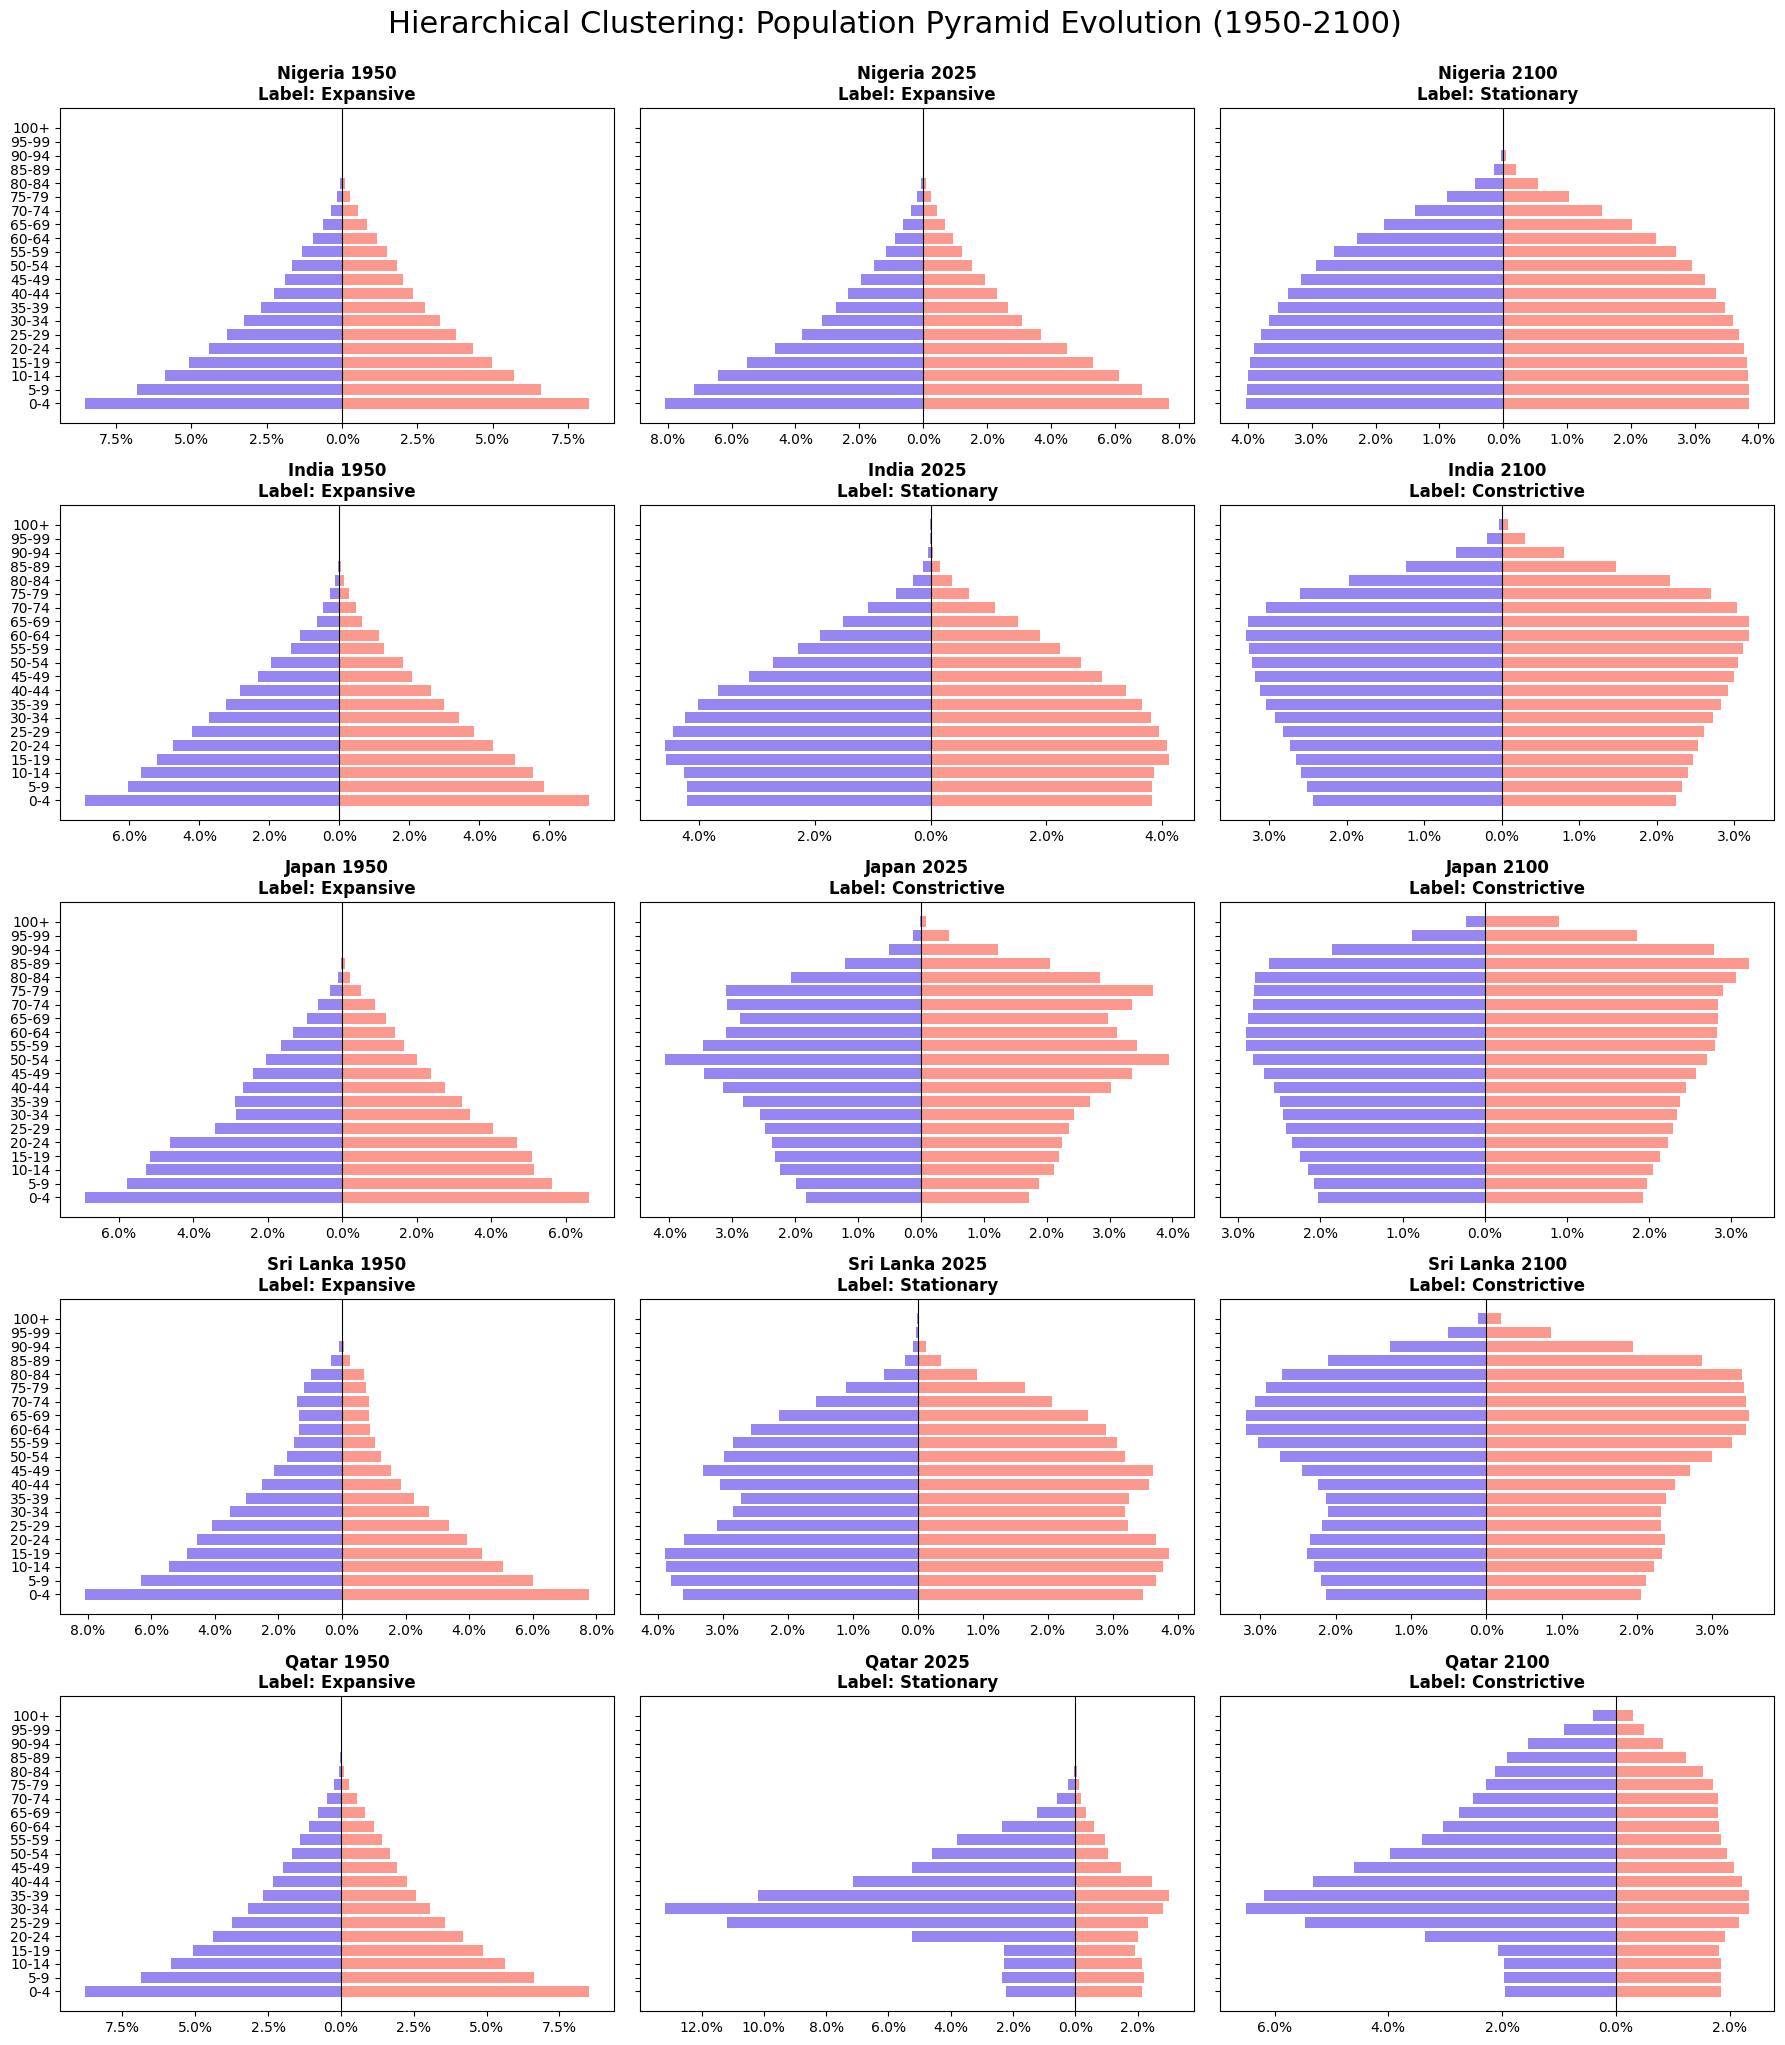

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- 1. PREPARE DATA & SORTING HELPER ---
# Extract number from AgeGrp (e.g., "5-9" -> 5) to fix the plotting sequence
df['age_sort'] = df['AgeGrp'].str.extract('(\d+)').astype(float)

# Prepare Data for Hierarchical Labels
X_pivot_data = df.pivot_table(index=['Location', 'Time'], columns='AgeGrp', values='PopTotal').fillna(0)
X_pct_global = X_pivot_data.div(X_pivot_data.sum(axis=1), axis=0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pct_global)
X_pca_global = PCA(n_components=0.95).fit_transform(X_scaled)

# Fit Hierarchical Model
hc_global = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
X_pivot_data['HC_Cluster'] = hc_global.fit_predict(X_pca_global)

# Determine Labels based on youth percentage
# We use the first column (usually 0-4) to rank clusters by "youthfulness"
youth_col = X_pct_global.columns[0]
youth_order = X_pct_global.groupby(X_pivot_data['HC_Cluster'])[youth_col].mean().sort_values(ascending=False).index
hc_label_map = {youth_order[0]: "Expansive", youth_order[1]: "Stationary", youth_order[2]: "Constrictive"}

# --- 2. PLOTTING THE PYRAMIDS ---
target_countries = ['Nigeria', 'India', 'Japan', 'Sri Lanka', 'Qatar']
target_years = [1950, 2025, 2100]

fig, axes = plt.subplots(len(target_countries), len(target_years), figsize=(18, 20), sharey=True)

for i, country in enumerate(target_countries):
    for j, year in enumerate(target_years):
        ax = axes[i, j]

        # Filter and SORT using the age_sort helper
        country_data = df[(df['Location'] == country) & (df['Time'] == year)].sort_values('age_sort')

        if country_data.empty: continue

        # Retrieve the pre-calculated cluster label
        cluster_id = X_pivot_data.loc[(country, year), 'HC_Cluster']
        label = hc_label_map[cluster_id]

        # Percentages for scale
        total = country_data['PopTotal'].sum()
        m_pct = (country_data['PopMale'] / total) * 100
        f_pct = (country_data['PopFemale'] / total) * 100
        ages = country_data['AgeGrp']

        # Plot
        ax.barh(ages, -m_pct, color='mediumslateblue', alpha=0.8, label='Male')
        ax.barh(ages, f_pct, color='salmon', alpha=0.8, label='Female')

        # Styling
        ax.set_title(f"{country} {year}\nLabel: {label}", fontsize=12, fontweight='bold')
        ax.axvline(0, color='black', linewidth=0.8)

        # Formatting X-axis to show positive percentage values
        ticks = ax.get_xticks()
        ax.set_xticklabels([f"{abs(x):.1f}%" for x in ticks])

plt.tight_layout()
plt.suptitle("Hierarchical Clustering: Population Pyramid Evolution (1950-2100)", fontsize=22, y=1.02)
plt.show()

In [ ]:
import plotly.express as px
import pandas as pd
import numpy as np

# 1. Choose the country you want to animate
target_country = 'India'  # Change this to any country in your CSV

# 2. Filter and Prepare Data
# Ensure we have the helper for sorting ages
df['age_sort'] = df['AgeGrp'].str.extract('(\d+)').astype(float)
anim_df = df[df['Location'] == target_country].sort_values(['Time', 'age_sort'])

# Calculate percentages for stable scaling across years
total_per_year = anim_df.groupby('Time')['PopTotal'].transform('sum')
anim_df['m_pct'] = (anim_df['PopMale'] / total_per_year) * -100 # Negative for left side
anim_df['f_pct'] = (anim_df['PopFemale'] / total_per_year) * 100

# Melt the data so Plotly can distinguish Male/Female by color
plot_df = anim_df.melt(
    id_vars=['Time', 'AgeGrp', 'age_sort'],
    value_vars=['m_pct', 'f_pct'],
    var_name='Gender', value_name='Percentage'
)

# 3. Create the Animated Plot
fig = px.bar(
    plot_df,
    y="AgeGrp",
    x="Percentage",
    color="Gender",
    animation_frame="Time",
    orientation='h',
    range_x=[-10, 10], # Adjust based on max percentage in your data
    color_discrete_map={'m_pct': 'royalblue', 'f_pct': 'hotpink'},
    title=f"Demographic Transformation of {target_country}: 1950 - 2100",
    labels={'Percentage': 'Percentage of Total Population'}
)

# 4. Refine the Layout
fig.update_layout(
    bargap=0.1,
    barmode='overlay',
    xaxis=dict(
        tickvals=[-8, -6, -4, -2, 0, 2, 4, 6, 8],
        ticktext=['8%', '6%', '4%', '2%', '0', '2%', '4%', '6%', '8%']
    )
)

# Optional: Add a label for the Spectral Cluster if you have it in a separate DF
# fig.add_annotation(...)

fig.show()

<>:10: SyntaxWarning:

invalid escape sequence '\d'

<>:10: SyntaxWarning:

invalid escape sequence '\d'

/tmp/ipykernel_20367/3421242474.py:10: SyntaxWarning:

invalid escape sequence '\d'



#pop pyramids variation 1950-2100 for srilanka , usa and oman

In [ ]:
import plotly.express as px
import pandas as pd

# 1. Setup Sorting Helper (Crucial for the "Video" flow)
df['age_sort'] = df['AgeGrp'].str.extract('(\d+)').astype(float)

def create_animated_pyramid(country_name):
    # Filter and Sort
    anim_df = df[df['Location'] == country_name].sort_values(['Time', 'age_sort'])

    # Calculate Percentages
    total_per_year = anim_df.groupby('Time')['PopTotal'].transform('sum')
    anim_df['m_pct'] = (anim_df['PopMale'] / total_per_year) * -100
    anim_df['f_pct'] = (anim_df['PopFemale'] / total_per_year) * 100

    # Melt for Plotly
    plot_df = anim_df.melt(
        id_vars=['Time', 'AgeGrp'],
        value_vars=['m_pct', 'f_pct'],
        var_name='Gender', value_name='Percentage'
    )

    # Create Animation
    fig = px.bar(
        plot_df,
        y="AgeGrp",
        x="Percentage",
        color="Gender",
        animation_frame="Time",
        orientation='h',
        range_x=[-10, 10], # Fixed scale to see the change clearly
        color_discrete_map={'m_pct': 'royalblue', 'f_pct': 'hotpink'},
        title=f"Demographic Evolution of {country_name} (1950 - 2100)",
        labels={'Percentage': 'Percent of Total Population'}
    )

    # Clean up Labels
    fig.update_layout(
        bargap=0.1,
        barmode='overlay',
        xaxis=dict(
            tickvals=[-8, -6, -4, -2, 0, 2, 4, 6, 8],
            ticktext=['8%', '6%', '4%', '2%', '0', '2%', '4%', '6%', '8%']
        )
    )
    return fig

# 2. Generate and Display the 3 Plots
fig_sl = create_animated_pyramid('Sri Lanka')
fig_usa = create_animated_pyramid('United States of America')
fig_oman = create_animated_pyramid('Oman')

fig_sl.show()
fig_usa.show()
fig_oman.show()

<>:5: SyntaxWarning:

invalid escape sequence '\d'

<>:5: SyntaxWarning:

invalid escape sequence '\d'

/tmp/ipykernel_20367/3858053598.py:5: SyntaxWarning:

invalid escape sequence '\d'

